# Bayesian prior exploration

This notebook provides exploratory analysis guiding our choice of priors for our pandemic intensity and duration distributions.

In [80]:
from itertools import product

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
import scipy
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

In [81]:
az.style.use("arviz-whitegrid")
cores = 4

# Duration modeling

We've chosen to model pandemic durations as following a lognormal distribution, i.e. the duration random variable $D$:

$$ln(D) \sim N(\mu, \sigma)$$

One implication of this modeling decision is that duration is rather fat-tailed. This captures evidently plausible outcomes such as HIV/AIDS, but fitting to the data leads to even 200 year+ pandemics receiving substantial probability density. Sensible treatment therefore requires ex post truncation. I currently truncate at ten years, as we have done previously; we'll presumably want to conduct sensitivity analysis to this choice.

Bayesian modeling in general lends itself well to encoding information about value ranges one finds plausible. Unfortunately, however, the lognomal distribution doesn't allow for straightforward control of the mean duration, as the mean is a function both of $\mu$ and $\sigma$ ($E[D] = e^{\mu + \sigma^2 / 2}$).

I will nonetheless proceed with the lognormal distribution, but we could consider whether alternative distributions might better reflect our views without ad hoc truncation.

In [82]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")
duration_data = final_allrisk_ds['duration']

For now we consider two different priors for the lognormal distribution:
1. **The common reference prior $\pi(\mu, \sigma) \propto \frac{1}{\sigma}$.**
	
	The prior is improper but provides a proper posterior with at least two observations. [Berger, Bernardo, and Sun (2015)](https://projecteuclid.org/journals/bayesian-analysis/volume-10/issue-1/Overall-Objective-Priors/10.1214/14-BA915.full) provide a helpful general overview of common reference priors.

2. **The [normal-inverse gamma (NIG) distribution](https://en.wikipedia.org/wiki/Normal-inverse_Gaussian_distribution).**
	
	NIG is a conjugate prior for the normal distribution, and as such yields an analytically integral posterior when combined with the lognormal log likelihood functions. The NIG distribution is characterized by the following distributional assumptions:
	
	$\sigma^2 \sim Inverse-gamma(\alpha_0, \beta_0)$, and $\mu | \sigma^2 \sim N(\mu_0, \frac{\sigma^2}{\kappa_0})$
	
	The parameters have the following interpretations:
	- $\mu_0$ is our prior guess for the log mean.
	- $\kappa_0$ is our prior confidence in $\mu$. It plays the same role as the square root of the sample size in determining the standard error in frequentist analysis.
	- $\alpha_0$ is a shape parameter that controls the 'peakiness' of the distribution. Higher $\alpha_0$ means more peaky.
	- $\beta_0$ is a scale parameter controlling the scale of the distribution.

The reference prior was chosen as it "let's the data speak maximally" (see [Berger, Bernardo, and Sun (2009)](https://projecteuclid.org/journals/annals-of-statistics/volume-37/issue-2/The-formal-definition-of-reference-priors/10.1214/07-AOS587.full)). The NIG prior was chosen because it yields an analytically tractable posterior. We can easily choose other priors if we want.

In [83]:
TRUNC_YEARS = 10

In [84]:
class LogNormalBayesianUpdater:
    def __init__(self, prior_type='reference', mu0=0, kappa0=0.01, alpha0=1.1, beta0=1):
        """
        Initialize the Bayesian updater.
        
        prior_type: 'reference' or 'NIG' (Normal-Inverse-Gamma)
        mu0, kappa0, alpha0, beta0: Hyperparameters for NIG prior
        """
        if prior_type not in ['reference', 'NIG']:
            raise ValueError("prior_type must be either 'reference' or 'NIG'")
        self.prior_type = prior_type
        self.mu0 = mu0
        self.kappa0 = kappa0
        self.alpha0 = alpha0
        self.beta0 = beta0

    def update(self, X):
        """
        Update posterior given observed data X (lognormal data).
        """
        self.X = X
        self.Y = np.log(X)  # work on log scale
        self.n = len(X)
        self.y_bar = np.mean(self.Y)
        self.S = np.sum((self.Y - self.y_bar) ** 2)

        if self.prior_type == 'NIG':
            self.kappa_n = self.kappa0 + self.n
            self.mu_n = (self.kappa0 * self.mu0 + self.n * self.y_bar) / self.kappa_n
            self.alpha_n = self.alpha0 + self.n / 2
            self.beta_n = (self.beta0 + 0.5 * self.S + 
                           0.5 * self.kappa0 * self.n * (self.y_bar - self.mu0)**2 / self.kappa_n)
        elif self.prior_type == 'reference':
            self.kappa_n = self.n
            self.mu_n = self.y_bar
            self.alpha_n = (self.n - 1) / 2
            self.beta_n = self.S / 2
    
    def sample_prior(self, n_samples=1000, rng=None):
        """
        Sample (mu, sigma) from the prior distribution.
        
        Parameters
        ----------
        n_samples : int
            Number of samples to draw from the prior distribution
            
        Returns
        -------
        tuple
            (mu_samples, sigma_samples) drawn from the prior distribution.
            Returns None, None if using reference prior since it is improper.
        """
        if self.prior_type == 'reference':
            print("Reference prior is improper (only defined up to proportionality). Skipping prior samples.")
            return None, None
            
        sigma2_samples = scipy.stats.invgamma.rvs(a=self.alpha0, scale=self.beta0, size=n_samples, random_state=rng)
        sigma_samples = np.sqrt(sigma2_samples)
        mu_samples = scipy.stats.norm.rvs(loc=self.mu0, scale=np.sqrt(sigma2_samples / self.kappa0), random_state=rng)
        
        return mu_samples, sigma_samples

    def sample_posterior(self, n_samples=1000, rng=None):
        """
        Sample (mu, sigma) from the posterior distribution.
        """
        sigma2_samples = scipy.stats.invgamma.rvs(a=self.alpha_n, scale=self.beta_n, size=n_samples, random_state=rng)
        sigma_samples = np.sqrt(sigma2_samples)
        mu_samples = scipy.stats.norm.rvs(loc=self.mu_n, scale=np.sqrt(sigma2_samples / self.kappa_n), random_state=rng)
        return mu_samples, sigma_samples
   
    def get_prior_grid(self, mu_range=None, sigma_range=None, n_points=100):
        """
        Calculate the analytical prior probability density function on a grid.
        
        Parameters
        ----------
        mu_range : tuple, optional
            Range of mu values (min, max). If None, determined automatically.
        sigma_range : tuple, optional
            Range of sigma values (min, max). If None, determined automatically.
        n_points : int, optional
            Number of points to use in each dimension, by default 50
            
        Returns
        -------
        dict
            Dictionary containing grid points and density values:
            - 'mu_grid': 2D array of mu values
            - 'sigma_grid': 2D array of sigma values 
            - 'density': 2D array of density values
        """
        if self.prior_type == 'reference':
            print("Reference prior is improper. Cannot calculate analytical PDF.")
            return None
        
        # Generate grid of points
        if mu_range is None: # Three expected stds around mean
            mu_range = (self.mu0 - 3 * np.sqrt(self.beta0 / ((self.alpha0 - 1) * self.kappa0)), # 
                        self.mu0 + 3 * np.sqrt(self.beta0 / ((self.alpha0 - 1) * self.kappa0)))
        
        if sigma_range is None:
            mode_sigma = np.sqrt(self.beta0 / (self.alpha0 + 1 + 0.5))  # Mode of inverse gamma
            sigma_range = (mode_sigma / 3, mode_sigma * 3)
        
        mu_grid = np.linspace(*mu_range, n_points)
        sigma_grid = np.linspace(*sigma_range, n_points)
        MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
        
        # Calculate prior density
        SIGMA2 = SIGMA ** 2
        prior_density = np.zeros_like(MU)
        
        # p(mu, sigma²) = p(mu|sigma²) * p(sigma²)
        # p(mu|sigma²) = Normal(mu0, sigma²/kappa0)
        # p(sigma²) = InvGamma(alpha0, beta0)
        for i in range(n_points):
            for j in range(n_points):
                mu_density = scipy.stats.norm.pdf(MU[i,j], loc=self.mu0, scale=np.sqrt(SIGMA2[i,j] / self.kappa0))
                sigma2_density = scipy.stats.invgamma.pdf(SIGMA2[i,j], a=self.alpha0, scale=self.beta0)
                prior_density[i,j] = mu_density * sigma2_density
                
        return pd.DataFrame({
            'mu': MU.flatten(),
            'sigma': SIGMA.flatten(),
            'density': prior_density.flatten()
        })

    def get_posterior_grid(self, mu_range=None, sigma_range=None, n_points=100):
        """
        Calculate the analytical posterior probability density function on a grid.
        
        Parameters
        ----------
        mu_range : tuple, optional
            Range of mu values (min, max). If None, determined automatically.
        sigma_range : tuple, optional
            Range of sigma values (min, max). If None, determined automatically.
        n_points : int, optional
            Number of points to use in each dimension, by default 50
            
        Returns
        -------
        dict
            Dictionary containing grid points and density values:
            - 'mu_grid': 2D array of mu values
            - 'sigma_grid': 2D array of sigma values
            - 'density': 2D array of density values
        """
        # Generate grid of points
        if mu_range is None:
            mu_range = (self.mu_n - 3 * np.sqrt(self.beta_n / ((self.alpha_n - 1) * self.kappa_n)), 
                        self.mu_n + 3 * np.sqrt(self.beta_n / ((self.alpha_n - 1) * self.kappa_n)))
        
        if sigma_range is None:
            mode_sigma = np.sqrt(self.beta_n / (self.alpha_n + 1 + 0.5))  # Mode of inverse gamma
            sigma_range = (mode_sigma / 3, mode_sigma * 3)
        
        mu_grid = np.linspace(mu_range[0], mu_range[1], n_points)
        sigma_grid = np.linspace(sigma_range[0], sigma_range[1], n_points)
        MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
        
        # Calculate posterior density
        SIGMA2 = SIGMA**2
        posterior_density = np.zeros_like(MU)
        
        # p(mu, sigma²|data) = p(mu|sigma², data) * p(sigma²|data)
        # p(mu|sigma², data) = Normal(mu_n, sigma²/kappa_n)
        # p(sigma²|data) = InvGamma(alpha_n, beta_n)
        for i in range(n_points):
            for j in range(n_points):
                mu_density = scipy.stats.norm.pdf(MU[i,j], loc=self.mu_n, scale=np.sqrt(SIGMA2[i,j] / self.kappa_n))
                sigma2_density = scipy.stats.invgamma.pdf(SIGMA2[i,j], a=self.alpha_n, scale=self.beta_n)
                posterior_density[i,j] = mu_density * sigma2_density
                
        return pd.DataFrame({
            'mu': MU.flatten(),
            'sigma': SIGMA.flatten(),
            'density': posterior_density.flatten()
        })
    

### Calibrate prior distribution

For the NIG prior, we want to calibrate it such that it captures our expectations for pandemic duration.

The CEPI expert survey asked the following question:

> *We assume that for the majority of pandemics, 75% of the mortality, financial harm, and school closures from pandemics peaks within the first two years after the outbreak occurred We use this to specify how long to calculate costs (e.g., investments in surge response) and benefits. Is this:*
>	- *Too high*
>	- *About right*
>	- *Too low*
>
>	*Comments:___________*

Three experts say too high, two say about right, and one who says too low while clarifying that it depends on whether vaccines/therapeutics are available.

Based on these responses, I propose starting by calibrating a prior that in expectation is four years long, puts 1/6 of the model prior probability < 2 years, 1/3 probability 2-3 years, and 1/2 probability more than three years. We also set low confidence in our mean estimate ($\kappa = 2$). $\alpha$ and $\beta$ are calibrated to satisfy their expectations, although this may not be the most correct.

We can later consider additional constraints such as calibrations to certains likelihood of outcomes. I.e. less than 5% probability of pandemic longer than 20 years in median prior.

In [85]:
# Calibrate central moments for NIG prior
def calibrate_lognormal_interval(mean_target, lower, upper, interval_prob):
    """Calibrate (mu, sigma) so that E[X]=mean_target and P(lower<=X<=upper)=interval_prob."""
    def eq(vars):
        mu, sigma = vars
        m = np.exp(mu + sigma**2/2) - mean_target
        cdf = scipy.stats.norm.cdf
        p = cdf((np.log(upper)-mu)/sigma) - cdf((np.log(lower)-mu)/sigma) - interval_prob
        return [m, p]
    
    mu_init, sigma_init = np.log(mean_target), 0.3
    return scipy.optimize.fsolve(eq, [mu_init, sigma_init])

def calibrate_lognormal_three_bins(mean_target, t1, t2, p_lt_t1, p_between, max_iter=1000):
    """Calibrate (mu, sigma) under three bin constraints and report residuals."""
    from scipy.optimize import least_squares
    
    def residuals(vars):
        mu, sigma = vars
        mean_res = np.exp(mu + sigma**2/2) - mean_target
        cdf1 = scipy.stats.norm.cdf((np.log(t1)-mu)/sigma)
        cdf2 = scipy.stats.norm.cdf((np.log(t2)-mu)/sigma)
        p1_res = cdf1 - p_lt_t1
        p2_res = (cdf2 - cdf1) - p_between
        return np.array([mean_res, p1_res, p2_res])
    
    mu0, sigma0 = np.log(mean_target), 0.4
    sol = least_squares(residuals, (mu0, sigma0), bounds=([-10,1e-3],[10,5]), max_nfev=max_iter)
    
    if not sol.success:
        raise RuntimeError("Calibration failed: "+sol.message)
    
    resid_vec = residuals(sol.x)
    resid_norm = float(np.linalg.norm(resid_vec))
    return float(sol.x[0]), float(sol.x[1]), resid_vec, resid_norm

def calibrate_nig_prior(mu_target, sigma_target, kappa0=1, alpha0=2):
    """Return (mu0, kappa0, alpha0, beta0) so that E[μ]=mu_target and E[σ²]=sigma_target²."""
    mu0 = mu_target
    beta0 = (alpha0 - 1) * sigma_target ** 2  # sets E[σ²]=sigma_target²
    return mu0, kappa0, alpha0, beta0

def calibrate_nig_with_tail(mu0, kappa0, alpha0, *, tail_thresh=10, tail_prob=0.05,
                            max_iter=40, draws_mc=40000, tol=2e-3):
    """Solve for beta0 so that P(exp(mu+σ²/2) > tail_thresh) ≈ tail_prob.

    Keeps (mu0, kappa0, alpha0) fixed.  Uses Monte‑Carlo inside a bisection search.
    Returns (beta0, achieved_prob).
    """
    lnT = np.log(tail_thresh)
    rng = np.random.default_rng()

    def tail_prob(beta):
        sigma2 = scipy.stats.invgamma.rvs(alpha0, scale=beta, size=draws_mc, random_state=rng)
        mu = rng.normal(mu0, np.sqrt(sigma2 / kappa0))
        return float(np.mean(mu + 0.5 * sigma2 > lnT))

    # bracket β so that prob_high < tail_prob < prob_low
    beta_low, beta_high = 1e-4, 50.0
    for _ in range(max_iter):
        beta_mid = (beta_low + beta_high) / 2
        p_mid = tail_prob(beta_mid)
        if p_mid > tail_prob:
            beta_low = beta_mid  # want smaller prob: shrink beta
        else:
            beta_high = beta_mid
        if abs(p_mid - tail_prob) < tol:
            break
    beta_final = beta_high
    p_final = tail_prob(beta_final)
    return beta_final, p_final

# -----------------------------------------------------------------------------
# Plot survival envelope induced by an NIG prior
# -----------------------------------------------------------------------------

def plot_survival_from_nig(mu0, kappa0, alpha0, beta0, *,
                           t_max=TRUNC_YEARS, n_points=1000, n_draws=50000, cred=0.90,
                           ax=None, label="NIG prior", color="C0"):
    """Visualise the distribution of survival curves implied by an NIG prior.

    Draws `n_draws` samples of (mu, sigma²) ~ NIG and plots the median survival
    function plus a central credible band of width `cred` (default 90%).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    # sample sigma² then mu
    sigma2 = scipy.stats.invgamma.rvs(alpha0, scale=beta0, size=n_draws)
    sigma = np.sqrt(sigma2)
    mu = scipy.stats.norm.rvs(loc=mu0, scale=np.sqrt(sigma2/kappa0))

    t = np.linspace(1e-6, t_max, n_points)
    surv_samples = scipy.stats.lognorm.sf(t[:, None], sigma, scale=np.exp(mu))  # shape [T, draws]
    print(surv_samples.shape)

    median = np.median(surv_samples, axis=1)
    lower = np.quantile(surv_samples, (1-cred)/2, axis=1)
    upper = np.quantile(surv_samples, 1-(1-cred)/2, axis=1)

    ax.plot(t, lower, color=color, linestyle='--')
    ax.plot(t, median, color=color, lw=2, label=f"Median")
    ax.plot(t, upper, color=color, linestyle='--', label=f"{int(cred*100)}% credible interval")
    
    ax.set_title("Duration distribution prior")
    ax.set_xlabel("Years")
    ax.set_ylabel("Exceedance probability")
    ax.set_xlim(0, t_max)
    ax.grid(True, which="both", ls=":", lw=0.6)
    ax.legend()
    return ax

LogNormal (mean≈3.43, P[2≤X≤3]=1/3): mu=1.1350, sigma=0.4392
Residual:[-0.00396983 -0.0094763  -0.02351626]
NIG prior: (sigma^2 ~ IG(2.00, 0.19, ~ N(1.13, sigma^2 / 2.00)))
(1000, 50000)


<Axes: title={'center': 'Duration distribution prior'}, xlabel='Years', ylabel='Exceedance probability'>

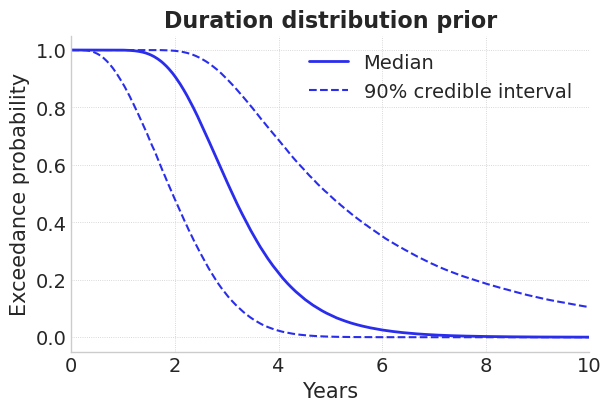

In [86]:
mu_target, sigma_target, resid_vec, resid_norm = calibrate_lognormal_three_bins(mean_target=3.43, t1=2, t2=3, p_lt_t1=1/6, p_between=1/3)
print(f"LogNormal (mean≈3.43, P[2≤X≤3]=1/3): mu={mu_target:.4f}, sigma={sigma_target:.4f}")
print(f"Residual:{resid_vec}")

mu0, kappa0, alpha0, beta0 = calibrate_nig_prior(mu_target, sigma_target,
                                                 kappa0=2, # Minimal information assumption
                                                 alpha0=2 # Minimal information assumption
                                                 )
print(f"NIG prior: (sigma^2 ~ IG({alpha0:.2f}, {beta0:.2f}, ~ N({mu0:.2f}, sigma^2 / {kappa0:.2f})))")

plot_survival_from_nig(mu0, kappa0, alpha0, beta0)

We now fit posterior distributions using our pandemic duration data. We also provide an MLE estimate of the model parameters for comparison.

C:\Users\squaade\AppData\Local\Temp\ipykernel_43012\949487865.py:100: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


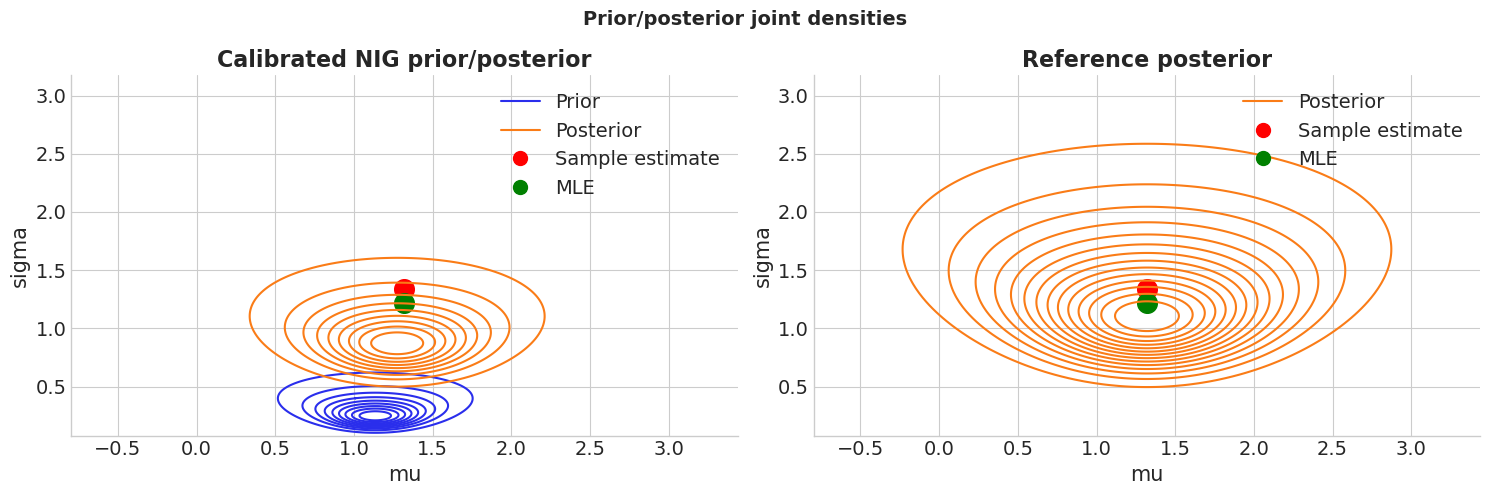

In [87]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Prior/posterior joint densities', fontsize=14)

# Get true parameters from data
sample_mu = np.log(duration_data).mean()
sample_sigma = np.log(duration_data).std()

# 2. Calibrated NIG prior using parameters from above
cal_nig_updater = LogNormalBayesianUpdater(prior_type='NIG', mu0=mu0, kappa0=kappa0, alpha0=alpha0, beta0=beta0)
cal_nig_updater.update(duration_data)
cal_prior = cal_nig_updater.get_prior_grid()
cal_post = cal_nig_updater.get_posterior_grid()
cal_prior['type'] = 'Prior'
cal_post['type'] = 'Posterior'
nig_df = pd.concat([cal_prior, cal_post])

# 3. Reference prior
ref_updater = LogNormalBayesianUpdater(prior_type='reference')
ref_updater.update(duration_data)
ref_post = ref_updater.get_posterior_grid()

# Plot results
titles = ['Calibrated NIG prior/posterior', 'Reference posterior']
dfs = [nig_df, ref_post]

# Get overall min/max for consistent axes
all_mu = pd.concat([df['mu'] for df in dfs])
all_sigma = pd.concat([df['sigma'] for df in dfs])
mu_min, mu_max = all_mu.min(), all_mu.max()
sigma_min, sigma_max = all_sigma.min(), all_sigma.max()

# Fit MLE lognormal
mle_params = scipy.stats.lognorm.fit(duration_data, floc=0)
mle_sigma, _, mle_mu = mle_params  # fit returns (s, loc, scale)
mle_mu = np.log(mle_mu)  # Convert scale to mu
# Define colors for prior and posterior
prior_color = sns.color_palette()[0]  # First color in default palette
post_color = sns.color_palette()[1]   # Second color in default palette

for i, (title, df) in enumerate(zip(titles, dfs)):
    ax = axes[i]
    if i == 0:  # For NIG priors
        sns.kdeplot(
            data=df,
            x='mu',
            y='sigma', 
            weights='density',
            hue='type',
            fill=False,
            levels=10,
            common_norm=False,
            ax=ax,
            bw_adjust=1.0,
            cut=0,
            palette=[prior_color, post_color],  # Set consistent colors
            label='Prior/Posterior'
        )
    else:  # For reference prior
        sns.kdeplot(
            data=df,
            x='mu',
            y='sigma',
            weights='density', 
            fill=False,
            levels=15,
            ax=ax,
            bw_adjust=1.0,
            cut=0,
            color=post_color,  # Use posterior color
            label='Posterior'
        )
    
    # Add true value point
    ax.scatter(sample_mu, sample_sigma, color='red', s=200, label='Sample estimate')
    ax.scatter(mle_mu, mle_sigma, color='green', s=200, label='MLE')
    
    ax.set_title(title)
    
    # Set consistent axis limits
    ax.set_xlim(mu_min, mu_max)
    ax.set_ylim(sigma_min, sigma_max)
    
    # Add legend with all elements
    if i == 0:
        handles = [
            plt.Line2D([], [], color=prior_color, label='Prior'),
            plt.Line2D([], [], color=post_color, label='Posterior'),
            plt.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Sample estimate'),
            plt.Line2D([], [], color='green', marker='o', linestyle='None', markersize=10, label='MLE')
        ]
    else:
        handles = [
            plt.Line2D([], [], color=post_color, label='Posterior'),
            plt.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Sample estimate'),
            plt.Line2D([], [], color='green', marker='o', linestyle='None', markersize=10, label='MLE')
        ]
    ax.legend(handles=handles)

plt.tight_layout()
plt.show()

Reminder that we don't display a prior for the reference prior approach as it is improper.

Next we plot the posterior exceedance curves. We also plot the MLE model for comparison.

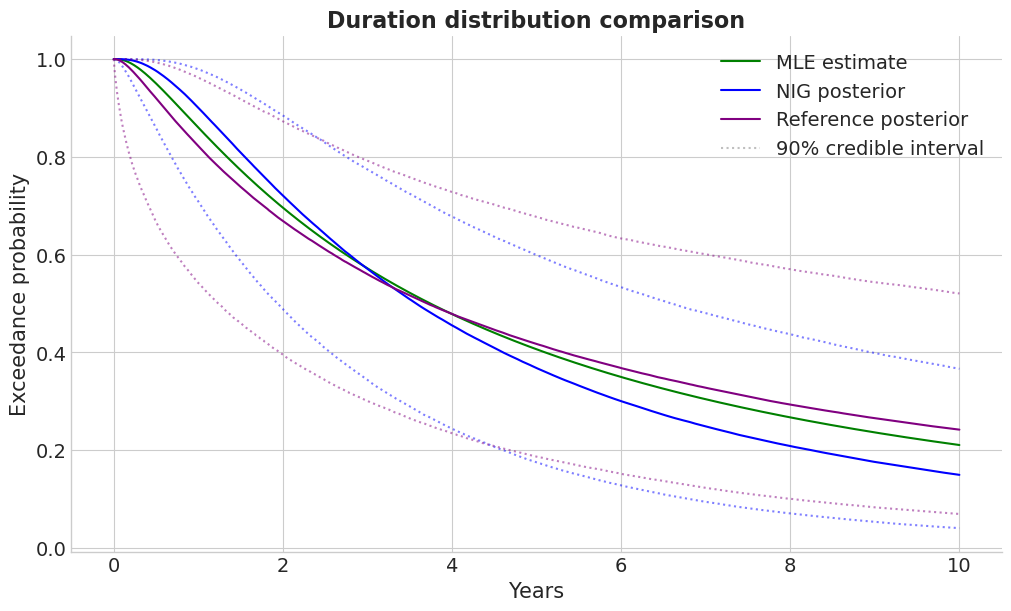

In [102]:
# Create figure with consistent styling
plt.figure(figsize=(10, 6))

# Time points for survival function
t = np.linspace(0, TRUNC_YEARS, 1000)

# Sample from posterior distributions
n_samples = 10_000
# NIG posterior samples from calibrated NIG updater
cal_mu_samples, cal_sigma_samples = cal_nig_updater.sample_posterior(n_samples)
nig_samples = pd.DataFrame({
    'mu': cal_mu_samples,
    'sigma': cal_sigma_samples
})

# Reference posterior samples from reference updater
ref_mu_samples, ref_sigma_samples = ref_updater.sample_posterior(n_samples) 
ref_samples = pd.DataFrame({
    'mu': ref_mu_samples,
    'sigma': ref_sigma_samples
})

# Calculate survival functions for each sample
t_mat = np.tile(t, (n_samples, 1)).T
nig_survivals = scipy.stats.lognorm.sf(t_mat, s=cal_sigma_samples, scale=np.exp(cal_mu_samples)) 
ref_survivals = scipy.stats.lognorm.sf(t_mat, s=ref_sigma_samples, scale=np.exp(ref_mu_samples))

# Calculate percentiles for credible intervals
nig_percentiles = np.percentile(nig_survivals, [5, 50, 95], axis=1)
ref_percentiles = np.percentile(ref_survivals, [5, 50, 95], axis=1)

# MLE survival function
mle_survival = 1 - scipy.stats.lognorm.cdf(t, s=mle_sigma, scale=np.exp(mle_mu))

# Plot using consistent colors from previous plots
plt.plot(t, mle_survival, color='green', label='MLE estimate')

# NIG posterior in blue
plt.plot(t, nig_percentiles[1], color='blue', label='NIG posterior')
plt.plot(t, nig_percentiles[0], color='blue', linestyle=':', alpha=0.5)
plt.plot(t, nig_percentiles[2], color='blue', linestyle=':', alpha=0.5)

# Reference posterior in purple 
plt.plot(t, ref_percentiles[1], color='purple', label='Reference posterior')
plt.plot(t, ref_percentiles[0], color='purple', linestyle=':', alpha=0.5)
plt.plot(t, ref_percentiles[2], color='purple', linestyle=':', alpha=0.5)

# Add a single dotted line to legend representing 90% credible intervals
plt.plot([], [], color='gray', linestyle=':', alpha=0.5, label='90% credible interval')

plt.xlabel('Years')
plt.ylabel('Exceedance probability')
plt.title('Duration distribution comparison')
plt.legend()
plt.grid(True)
plt.show()

To reassure ourselves that a Bayesian approach generally provides a good fit, I below run a set of experiments comparing MLE to a Bayesian approach with a misspecified NIG prior ($\mu_0 = 0, \sigma^2_0 = 1$). In general, I don't see large difference between the two methods.

C:\Users\squaade\AppData\Local\Temp\ipykernel_43012\2968976988.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend


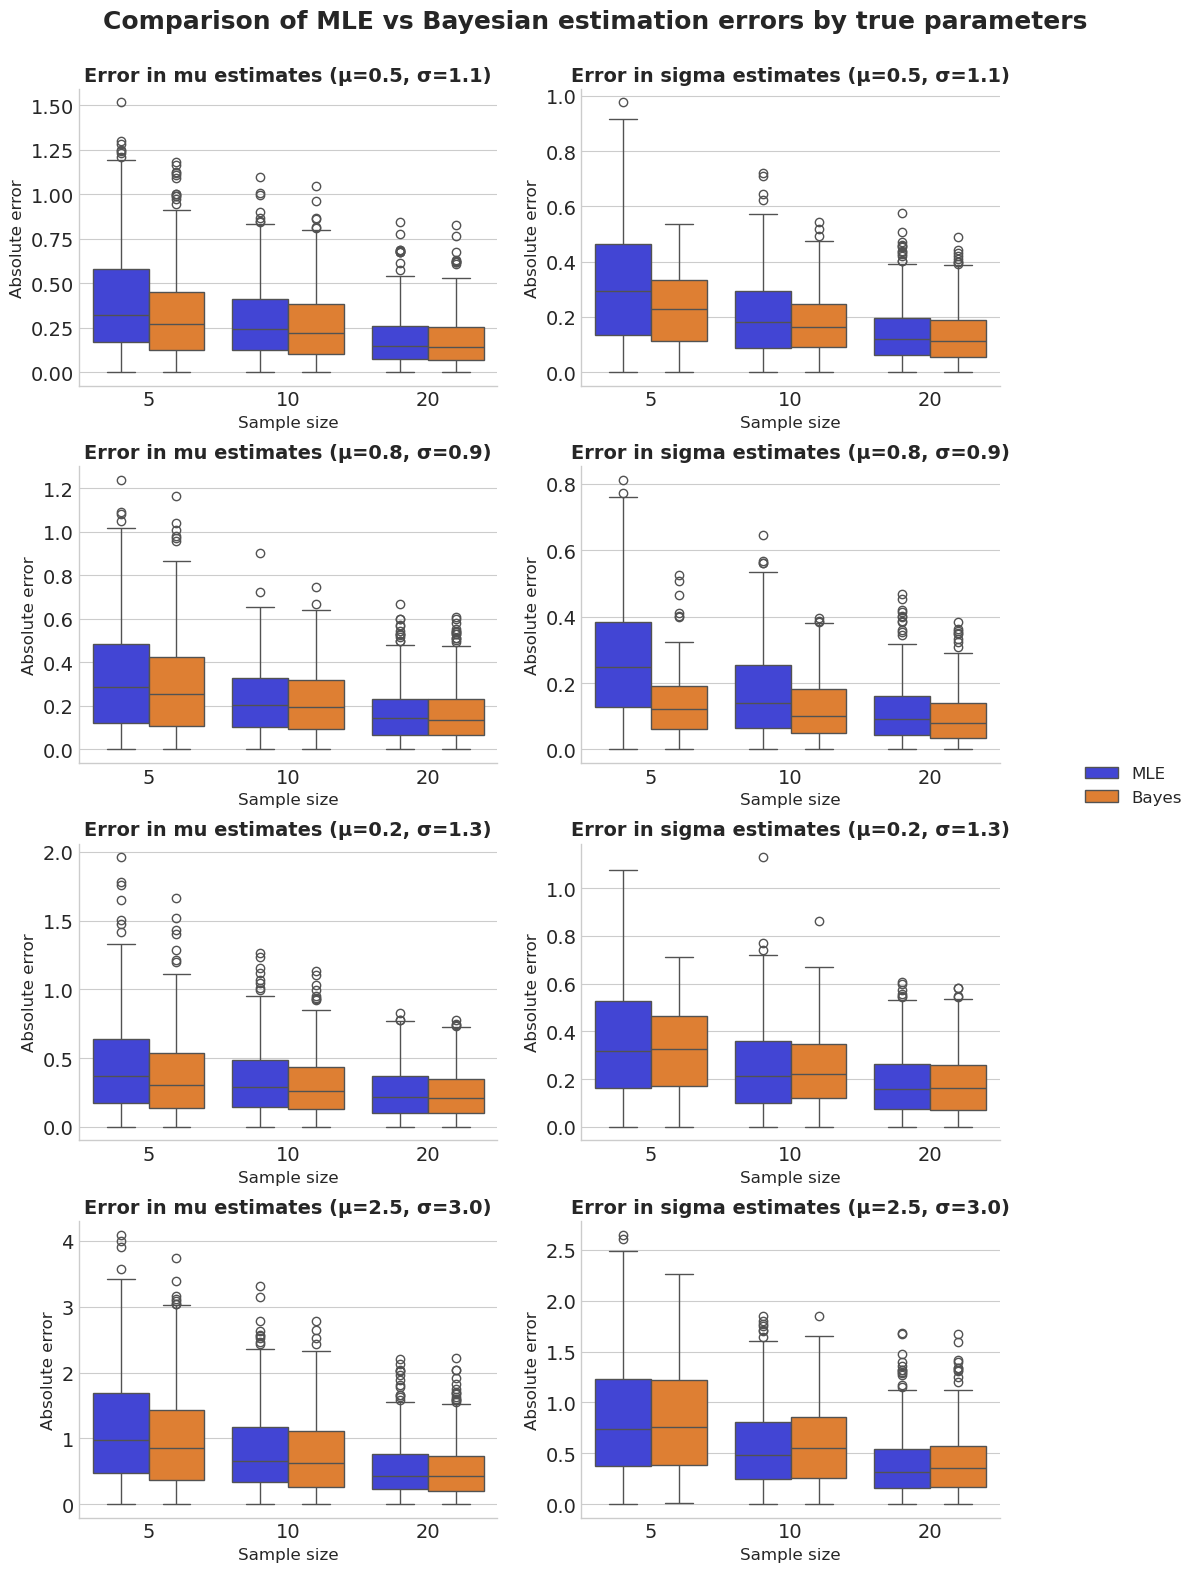

In [34]:
# Run experiments comparing MLE vs Bayesian estimation
np.random.seed(42)
n_experiments = 500
sample_sizes = [5, 10, 20]
# Test across different true parameter combinations
true_params = [
    (0.493, 1.099),  # Original calibrated values
    (0.8, 0.9),      # Higher mean, lower variance
    (0.2, 1.3),      # Lower mean, higher variance
    (2.5, 3) # High mean, high varian
]

results = {
    'sample_size': [],
    'method': [],
    'true_mu': [],
    'true_sigma': [],
    'mu_est': [],
    'sigma_est': [],
    'mu_error': [],
    'sigma_error': []
}

for true_mu, true_sigma in true_params:
    for n in sample_sizes:
        for i in range(n_experiments):
            # Generate sample from true lognormal
            sample = np.random.lognormal(true_mu, true_sigma, size=n)
            
            # MLE estimation
            mle_sigma, _, mle_scale = scipy.stats.lognorm.fit(sample, floc=0)
            mle_mu = np.log(mle_scale) # Convert from scale to mu
            
            # Bayesian estimation with NIG prior
            # Use misspecified prior parameters to test robustness
            mu0, kappa0, alpha0, beta0 = calibrate_nig_prior(mu_target=0, sigma_target=1)
            
            n_data = len(sample)
            xbar = np.mean(np.log(sample))
            s2 = np.var(np.log(sample))
            
            # Posterior parameters
            kappa_n = kappa0 + n_data
            mu_n = (kappa0 * mu0 + n_data * xbar) / kappa_n
            alpha_n = alpha0 + n_data/2
            beta_n = beta0 + 0.5 * ((n_data - 1)*s2 + 
                                   (n_data * kappa0 * (xbar - mu0)**2) / kappa_n)
            
            # Store results
            results['sample_size'].extend([n, n])
            results['method'].extend(['MLE', 'Bayes'])
            results['true_mu'].extend([true_mu, true_mu])
            results['true_sigma'].extend([true_sigma, true_sigma])
            results['mu_est'].extend([mle_mu, mu_n])
            results['sigma_est'].extend([mle_sigma, np.sqrt(beta_n/(alpha_n-1))])
            results['mu_error'].extend([abs(mle_mu - true_mu), abs(mu_n - true_mu)])
            results['sigma_error'].extend([abs(mle_sigma - true_sigma), 
                                         abs(np.sqrt(beta_n/(alpha_n-1)) - true_sigma)])
# Convert to DataFrame for analysis and create plots
results_df = pd.DataFrame(results)

# Create figure with subplots for different parameter combinations
unique_params = list(zip(results_df['true_mu'].unique(), results_df['true_sigma'].unique()))
n_params = len(unique_params)
fig, axes = plt.subplots(n_params, 2, figsize=(12, 4*n_params))
fig.suptitle('Comparison of MLE vs Bayesian estimation errors by true parameters', fontsize=18)

for i, (true_mu, true_sigma) in enumerate(unique_params):
    param_data = results_df[
        (results_df['true_mu'] == true_mu) & 
        (results_df['true_sigma'] == true_sigma)
    ]
    
    # Plot mu errors
    sns.boxplot(data=param_data, x='sample_size', y='mu_error', hue='method', ax=axes[i,0])
    axes[i,0].set_title(f'Error in mu estimates (μ={true_mu:.1f}, σ={true_sigma:.1f})', fontsize=14)
    axes[i,0].set_xlabel('Sample size', fontsize=12)
    axes[i,0].set_ylabel('Absolute error', fontsize=12)
    axes[i,0].legend().set_visible(False)

    # Plot sigma errors
    sns.boxplot(data=param_data, x='sample_size', y='sigma_error', hue='method', ax=axes[i,1])
    axes[i,1].set_title(f'Error in sigma estimates (μ={true_mu:.1f}, σ={true_sigma:.1f})', fontsize=14)
    axes[i,1].set_xlabel('Sample size', fontsize=12)
    axes[i,1].set_ylabel('Absolute error', fontsize=12)
    axes[i,1].legend().set_visible(False)

# Add a single legend to the right of the figure
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
fig.subplots_adjust(top=0.93)

# Pandemic intensity modeling

Let pandemic intensity $X$ be a random variable defined by the following cumulative distribution function:

$$
\mathrm{F_X}(x; p_0, \xi, \sigma) = \begin{cases}
     1 - p_0 & x < \mu \\
        1 - p_0\left(1+\xi\dfrac{x-\mu}{\sigma}\right)^{-1/\xi} & x \geq \mu
\end{cases}
$$

where $p_0$ is the annual probability that an epidemic emerges and $\xi$, $\mu$ and $\sigma$ are the shape, location, and scale parameters of a generalized Pareto distribution (GPD) representing pandemic intensity conditional on arrival. For simplicity we will henceforth denote $F_X(x;p_0, \xi, \sigma)$ as $F_X$.

The CEPI expert survey does not provide any information with which to calibrate our pandemic intensity prior distribution. We therefore adopt the common reference prior:

$$\pi(\xi, \theta, \lambda) \propto (1 + \xi)^{-1} \cdot \theta^{-1} \cdot (e^\lambda - 1)^{-1/2}$$

where $\theta = (1 + \xi)\cdot \sigma$ and $p_0 = 1 - e^{-\lambda}$.

Reference priors are attractive because "they let the data speak as much as possible." Formally, they maximize the expected Kullback-Leibler divergence between the prior and posterior (see [here](https://projecteuclid.org/journals/annals-of-statistics/volume-37/issue-2/The-formal-definition-of-reference-priors/10.1214/07-AOS587.full) for more).

The reparametrization in terms of $\theta$ is key, as it yields a Fisher information matrix guaranteeing the existence of a "common reference prior", i.e., one that is invariant to the sequence in which one conducts a marginalization procedure used in their construction (see [Berger, Bernardo and Sun (2015)](https://projecteuclid.org/journals/bayesian-analysis/volume-10/issue-1/Overall-Objective-Priors/10.1214/14-BA915.full)). A derivation of the common reference prior using this parametrization can be found in [Kang, Kim, and Lee (2013)](https://koreascience.or.kr/article/JAKO201306735656489.pdf). I posit that it is trivial to show that adding in arrival rate $p_0$ yields the same reference prior scaled by the Jeffrey's prior for $p_0$.

The reparametrization of $p_0$ in terms of $\lambda$ was adopted to improve the computational geometry of the MCMC posterior approximation, although this may be a vestige.

One downside of reference priors is that they are vulnerable to causing MCMC chains to diverge off into funnels when parameters yield extremes values in the prior. For our prior, this occurs when $\xi \to -1$ and $\theta \to 0$. To tame this behavior, we implement softplus functions below that nudge the chain in the opposite direction at the very extremes. These corrective nudges only impose themselves on the prior at the extremes, and should thus have negligible impact on the shape of our prior over our regions of interest.

One other downside of the reference prior approach is that it's not analytically tractable if we wanted to add truncation from above in the form of $F_{\bar{u}}(x) = \frac{F(x)}{F(\bar{u})}$ as we have done before. Instead, we either have to use [Cirillo and Taleb's log transformation](https://www.nature.com/articles/s41567-020-0921-x) or sharp ex post truncation.

In [35]:
# ---------- Data generator ----------
def rmix_gpd(n, lambda_true, sigma_true, xi_true, mu, rng=None):
    """Generate random samples from a mixture of point mass and GPD.
    
    Args:
        n (int): Number of samples to generate
        lambda_true (float): True Poisson arrival rate parameter
        sigma_true (float): True GPD scale parameter
        xi_true (float): True GPD shape parameter
        mu (float): Location parameter (threshold/point mass location)
        rng (numpy.random.Generator, optional): Random number generator. If None, a new one is created.
    
    Returns:
        numpy.ndarray: Array of n samples from the mixture distribution
    """
    rng = np.random.default_rng(rng)
    p_true = 1 - np.exp(-lambda_true)
    below_threshold = rng.random(n) < (1 - p_true) # δ = 0 (mass pt μ)
    n_below_threshold = below_threshold.sum()
    n_tail = n - n_below_threshold
    u = rng.random(n_tail)
    
    if abs(xi_true) < 1e-8:
        tail_x = mu - sigma_true * np.log(1 - u)  # Exponential limit
    else:
        tail_x = mu + sigma_true / xi_true * ((1 - u) ** (-xi_true) - 1)
        
    x = np.concatenate([np.full(n_below_threshold, mu), tail_x])
    rng.shuffle(x)
    
    return x

#### Define the model

In [36]:
class XiShiftSoftplus(pm.distributions.transforms.Transform):
    """Transform that applies a shifted softplus function.
    
    The transform is defined as:
    forward: f(x) = -shift + log(1 + exp(x))
    backward: f^(-1)(y) = log(exp(y + shift) - 1)
    log_jac_det: log|f'(y)| = y + shift - log(exp(y + shift) - 1)
    
    Parameters
    ----------
    shift : float, default=0.5
        Shift parameter that offsets the softplus function
    """
    def __init__(self, shift=0.5):
        self.shift=float(shift)
        
    def forward(self, x):
        """Forward transform: -shift + log(1 + exp(x))"""
        return -self.shift + pt.softplus(x)
    
    def backward(self, y):
        """Backward transform: log(exp(y + shift) - 1)"""
        return pt.log(pt.expm1(y + self.shift))
    
    def log_jac_det(self, y):
        """Log determinant of Jacobian: y + shift - log(exp(y + shift) - 1)"""
        return y + self.shift - pt.log(pt.expm1(y + self.shift))


def make_intensity_model(obs=None, threshold=None,
												 xi_shift=.5, xi_ceil=10.,
												 lambda_ceil=50.,
												 theta_floor=1e-5,
												 theta_ceil=1e4):
    """Create a model for the frequency-severity model with:
        • Bernoulli arrival prob  p = 1−exp(−λ)
        • GPD(μ, σ, ξ) severity
        
    	Using orthogonal parameterization with θ = (1+ξ)·σ.
        
      We introduce several softplus boundaries to control numerical overflows in likelihood funnels.
    
    Parameters
    ----------
    obs : array-like, optional
        Observations for likelihood
    threshold : float, optional
        GPD threshold, required if obs provided
    xi_shift : float, default=0.5
        Shift parameter for ξ transform
    xi_ceil : float, default=10.0
        Upper bound for ξ
    lambda_ceil : float, default=50.0
        Upper bound for λ
    theta_floor : float, default=1e-7
        Lower bound for θ
    theta_ceil : float, default=1e6
        Upper bound for θ
    
    Returns
    -------
    PyMC model
    """
    with pm.Model() as m:
				# ──────────────────────────────────────────────────────────────────────────────
				#  Reference prior — orthogonal parameterisation
				#
				#   ξ  : tail index            (ξ > −1)
				#   θ  = (1+ξ)·σ : orthogonal scale (θ > 0)
				#   λ  : latent Poisson arrival rate (λ > 0)
				#
				#   Reference prior:
				#      π(ξ,θ,λ) ∝ (1+ξ)⁻¹ · θ⁻¹ · (e^λ − 1)^−½
				# ──────────────────────────────────────────────────────────────────────────────

        # ─── ξ  ────────────────────────────────────────────────
        xi_raw = pm.Normal("xi_raw", 0, 2) # **auxiliary only**
        xi = pm.Deterministic("xi", XiShiftSoftplus(xi_shift).forward(xi_raw))

        pm.Potential("xi_ref",
										 -pt.log1p(xi)          # reference
										 -pt.softplus(-xi_raw)) # Jacobian
        pm.Potential("xi_cap", -1e3 * pt.softplus((xi - xi_ceil)/.02))      # smooth wall

        # ─── σ  &  θ ──────────────────────
        log_sigma = pm.Flat("log_sigma")                # improper flat
        sigma     = pm.Deterministic("sigma", pt.exp(log_sigma))
        theta     = pm.Deterministic("theta", sigma * (1 + xi))

        pm.Potential("theta_ref", -log_sigma - pt.log1p(xi))  # = –log θ
        pm.Potential("theta_floor",
            -1e3*pt.softplus((theta_floor - theta)/.05)) # keeps θ>0 numerically
        pm.Potential("theta_upper", -1e3*pt.softplus((pt.exp(log_sigma) * (1+xi) - theta_ceil)/1.)) # Keeps theta away from large values

        # ─── λ  &  p  (true Beta½ prior) ──────────────────────
        p = pm.Beta("p", .5, .5)
        lam = pm.Deterministic("lambda", -pt.log1p(-p))
        pm.Potential("lam_cap", -1e3 * pt.softplus((lam - lambda_ceil)/.1))  # hard ceiling on λ if you still want one (likewise smoothed)

        # ─── likelihood ───────────────────────────
        if obs is not None:
            if threshold is None:
                raise ValueError("Need `threshold` when observations supplied")
            is_tail = obs > threshold
            y = obs[is_tail] - threshold

            t = 1 + xi * y / sigma
            log_tail = -pt.log(sigma) - (1/xi + 1)*pt.log(t)

            ll = (pt.sum(pt.log1p(-p) * (~is_tail)) +
                  pt.sum(pt.log(p) + log_tail))
            pm.Potential("likelihood", ll)

    return m

In [37]:
THRESHOLD = 0.01
var_names = ['lambda', 'p', 'xi', 'theta', 'sigma']

We visualize the prior distributions.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [xi_raw, log_sigma, p]


Output()

Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 46 seconds.
There were 68 divergences after tuning. Increase `target_accept` or reparameterize.


Text(0.5, 0.98, 'Prior distributions')

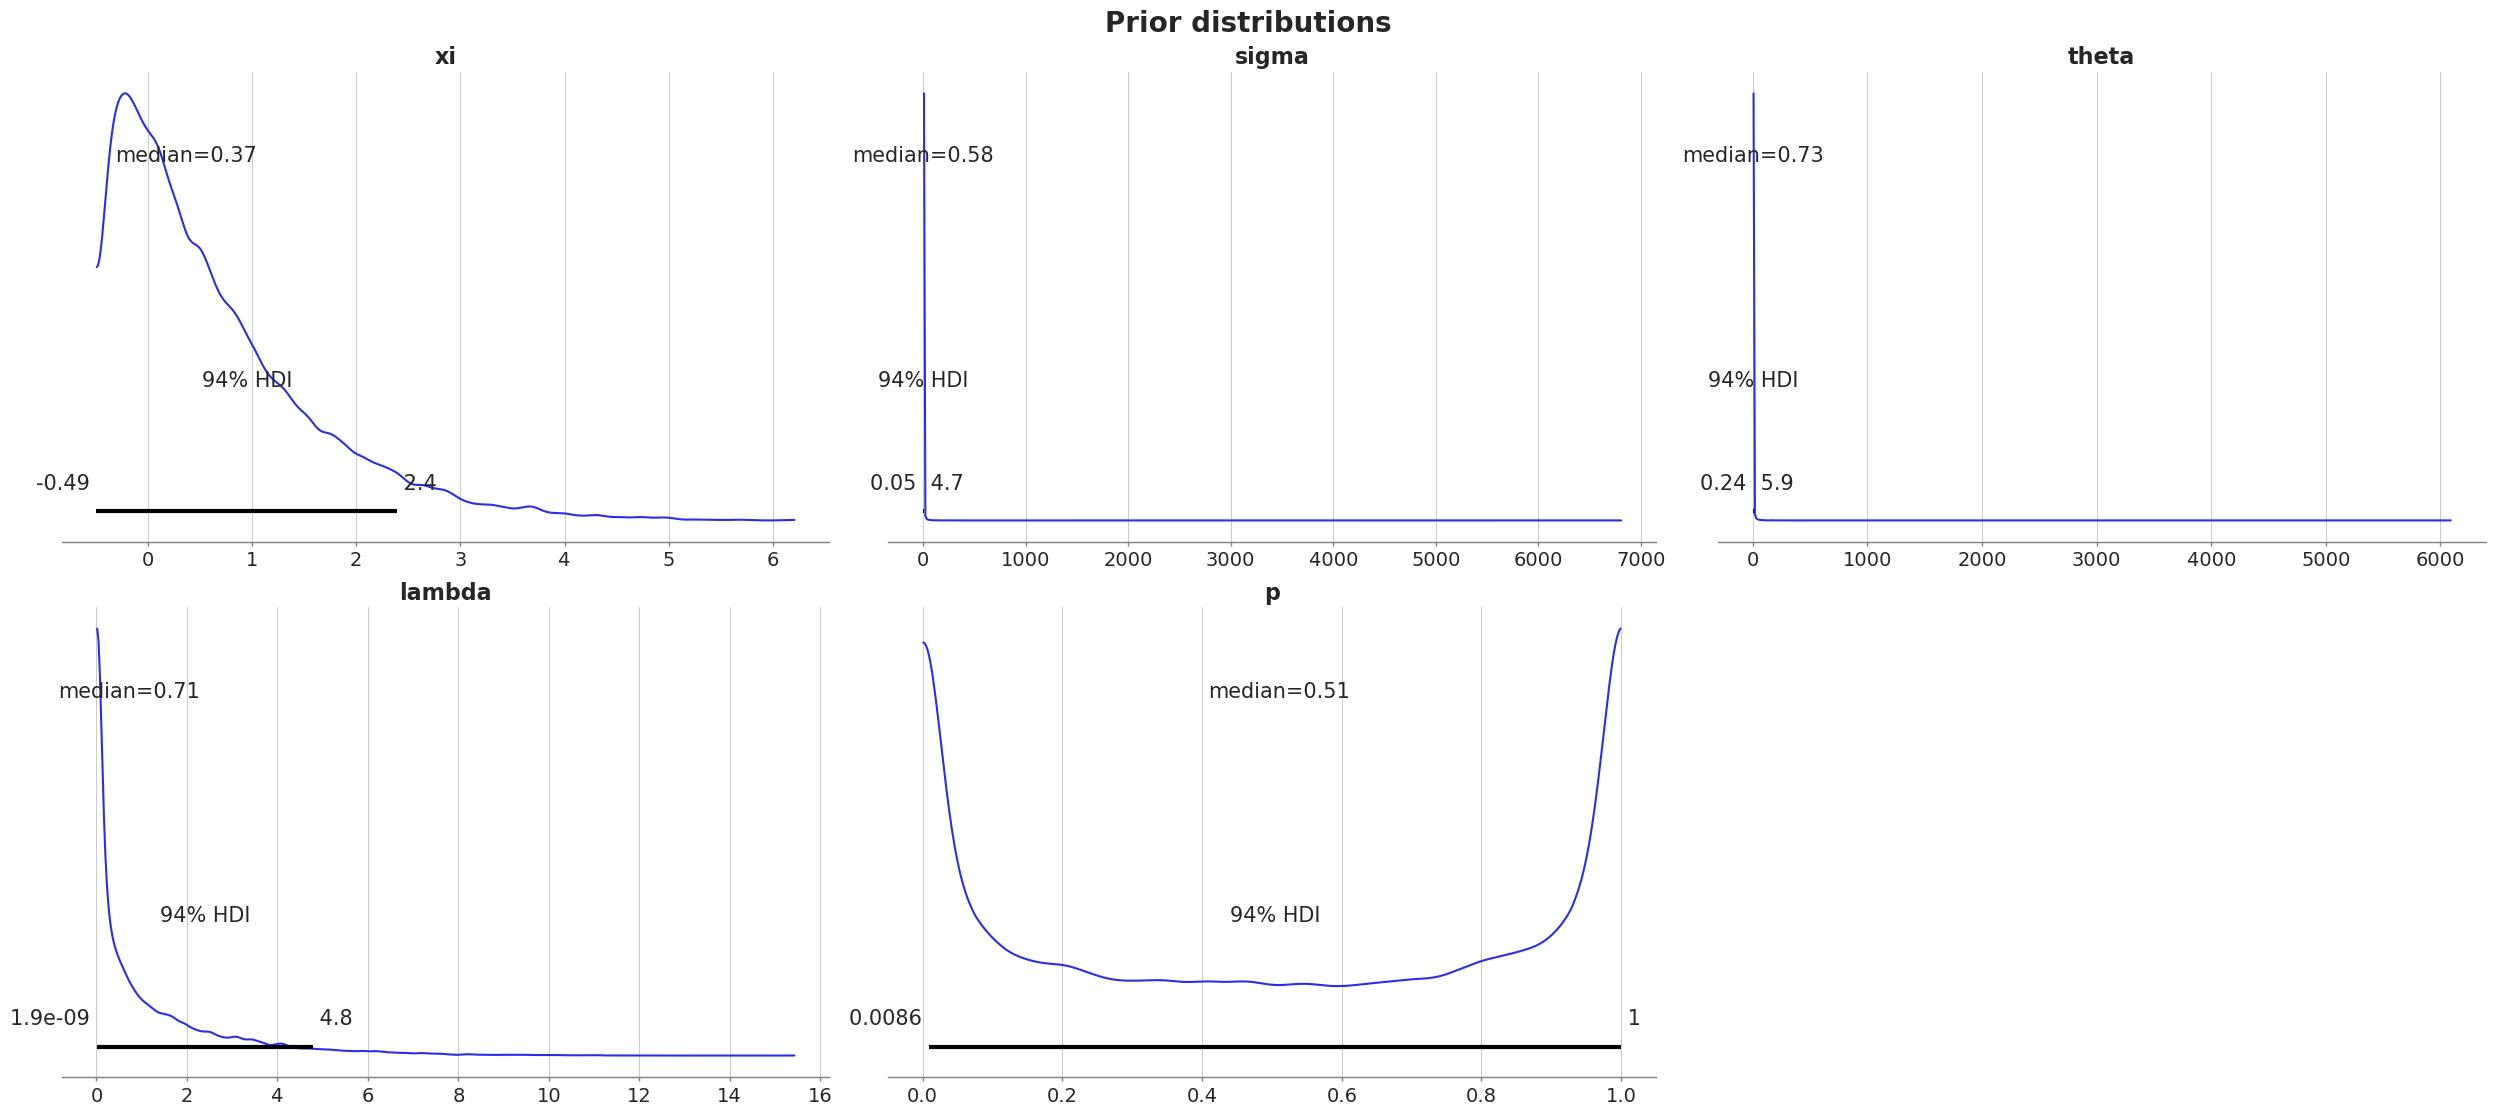

In [38]:
with make_intensity_model() as model:
    prior_trace = pm.sample( # Call pm.sample to ensure potentials are included
        draws=5000,
        tune=2000,
        chains=4,
        random_seed=42,
        discard_tuned_samples=True,
        target_accept=0.9
    )
    
az.plot_posterior(prior_trace, var_names=["xi", "sigma", "theta", "lambda", "p"], grid=(2,3), point_estimate='median')
plt.suptitle('Prior distributions', fontsize=20)

array([[<Axes: ylabel='sigma'>, <Axes: >],
       [<Axes: xlabel='xi', ylabel='p'>, <Axes: xlabel='sigma'>]],
      dtype=object)

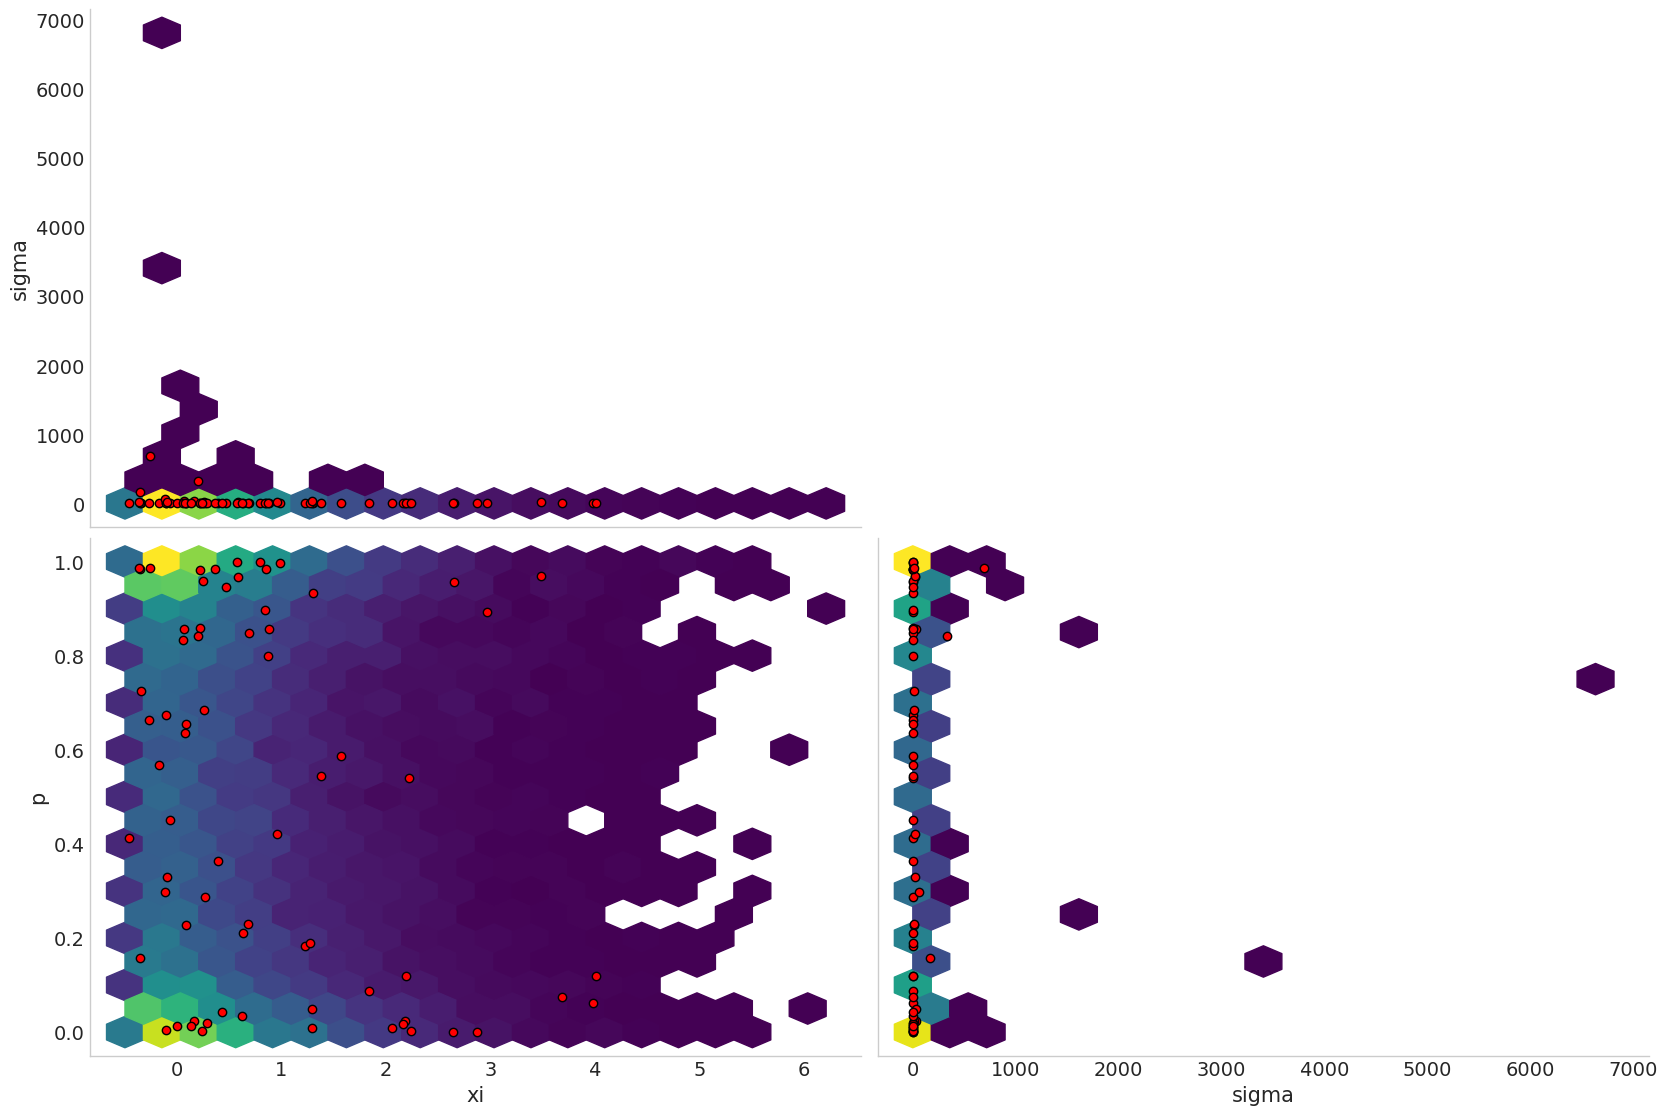

In [39]:
az.plot_pair(
    prior_trace,
    var_names=["xi", "sigma", "p"],
    kind="hexbin",
    divergences=True,
    divergences_kwargs={"color":"r"}
)

Almost all of the divergences occur when sigma is small, but there aren't very many. It looks like we've tamed the divergences!

Next, we run a series of experiments using hypothetical parameter values for our models. For each set of parameters, we generate several small samples with a similar number of observations as our true pandemic data. We then investigate how well posterior captures the true parameters. We also estimate MLE for the same datasets for comparison.

In [42]:
# ---- design grid ----
true_grid = list(product([0.1, 0.05], # lambda
                         [1.0, 2.0], # σ
                         [0.3, 1.2])) # ξ
sample_ns = [100, 200] # tiny samples
n_rep = 4 # repeats per cell
rng_master = np.random.default_rng(23)

In [ ]:
results = []
for (lambda0, s0, xi0), n in tqdm(list(product(true_grid, sample_ns))):
    for rep in range(n_rep):
        x = rmix_gpd(n, lambda0, s0, xi0, THRESHOLD, rng_master)
        with make_intensity_model(x, THRESHOLD):
            idata = pm.sample(draws=2000, tune=2000, chains=cores,
                              progressbar=False, random_seed=rng_master, target_accept=0.9)
        post = az.summary(idata, var_names=['xi', 'theta', 'lambda', 'p', 'sigma'], kind='all', hdi_prob=0.9)
        
        # Get posterior means, HDIs and rhat
        p_mean = post.loc["p","mean"]
        p_hdi_l = post.loc["p","hdi_5%"]
        p_hdi_u = post.loc["p","hdi_95%"]
        p_rhat = post.loc["p","r_hat"]
        
        lambda_mean = post.loc["lambda","mean"]
        lambda_hdi_l = post.loc["lambda","hdi_5%"]
        lambda_hdi_u = post.loc["lambda","hdi_95%"]
        lambda_rhat = post.loc["lambda","r_hat"]
        
        sigma_mean = post.loc["sigma","mean"]
        sigma_hdi_l = post.loc["sigma","hdi_5%"]
        sigma_hdi_u = post.loc["sigma","hdi_95%"]
        sigma_rhat = post.loc["sigma","r_hat"]
        
        xi_mean = post.loc["xi","mean"]
        xi_hdi_l = post.loc["xi","hdi_5%"]
        xi_hdi_u = post.loc["xi","hdi_95%"]
        xi_rhat = post.loc["xi","r_hat"]
        
        theta_mean = post.loc["theta","mean"]
        theta_hdi_l = post.loc["theta","hdi_5%"]
        theta_hdi_u = post.loc["theta","hdi_95%"]
        theta_rhat = post.loc["theta","r_hat"]
        
        # Compute MLE fit
        p_mle = (x > THRESHOLD).sum() / len(x)
        lambda_mle = -np.log(1-p_mle)
        exceed_points = x[x > THRESHOLD]
        xi_mle, loc_mle, sigma_mle = scipy.stats.genpareto.fit(exceed_points, floc=THRESHOLD)
        
        results.append({
            "lambda_true": lambda0,
            "p_true": 1 - np.exp(-lambda0),
            "sigma_true": s0, 
            "xi_true": xi0,
            "n": n,
            "p_hat": p_mean,
            "p_hdi_l": p_hdi_l,
            "p_hdi_u": p_hdi_u,
            "lambda_hat": lambda_mean,
            "lambda_hdi_l": lambda_hdi_l,
            "lambda_hdi_u": lambda_hdi_u,
            "sigma_hat": sigma_mean,
            "sigma_hdi_l": sigma_hdi_l, 
            "sigma_hdi_u": sigma_hdi_u,
            "xi_hat": xi_mean,
            "xi_hdi_l": xi_hdi_l,
            "xi_hdi_u": xi_hdi_u,
            "theta_hat": theta_mean,
            "theta_hdi_l": theta_hdi_l,
            "theta_hdi_u": theta_hdi_u,
            "sample_ns": n,
            "num_above_THRESHOLD": (x > THRESHOLD).sum(),
            'p_mle': p_mle,
            'lambda_mle': lambda_mle,
            'xi_mle': xi_mle,
            'sigma_mle': sigma_mle
        })

df = pd.DataFrame(results)
df.to_csv("sim_small_sample.csv", index=False)

In [31]:
# Add prior distribution for p
prior = prior_trace.posterior
prior_p = prior['p'].values.flatten()
prior_sigma = prior['sigma'].values.flatten()
prior_xi = prior['xi'].values.flatten()

C:\Users\squaade\AppData\Local\Temp\ipykernel_23116\2560042349.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


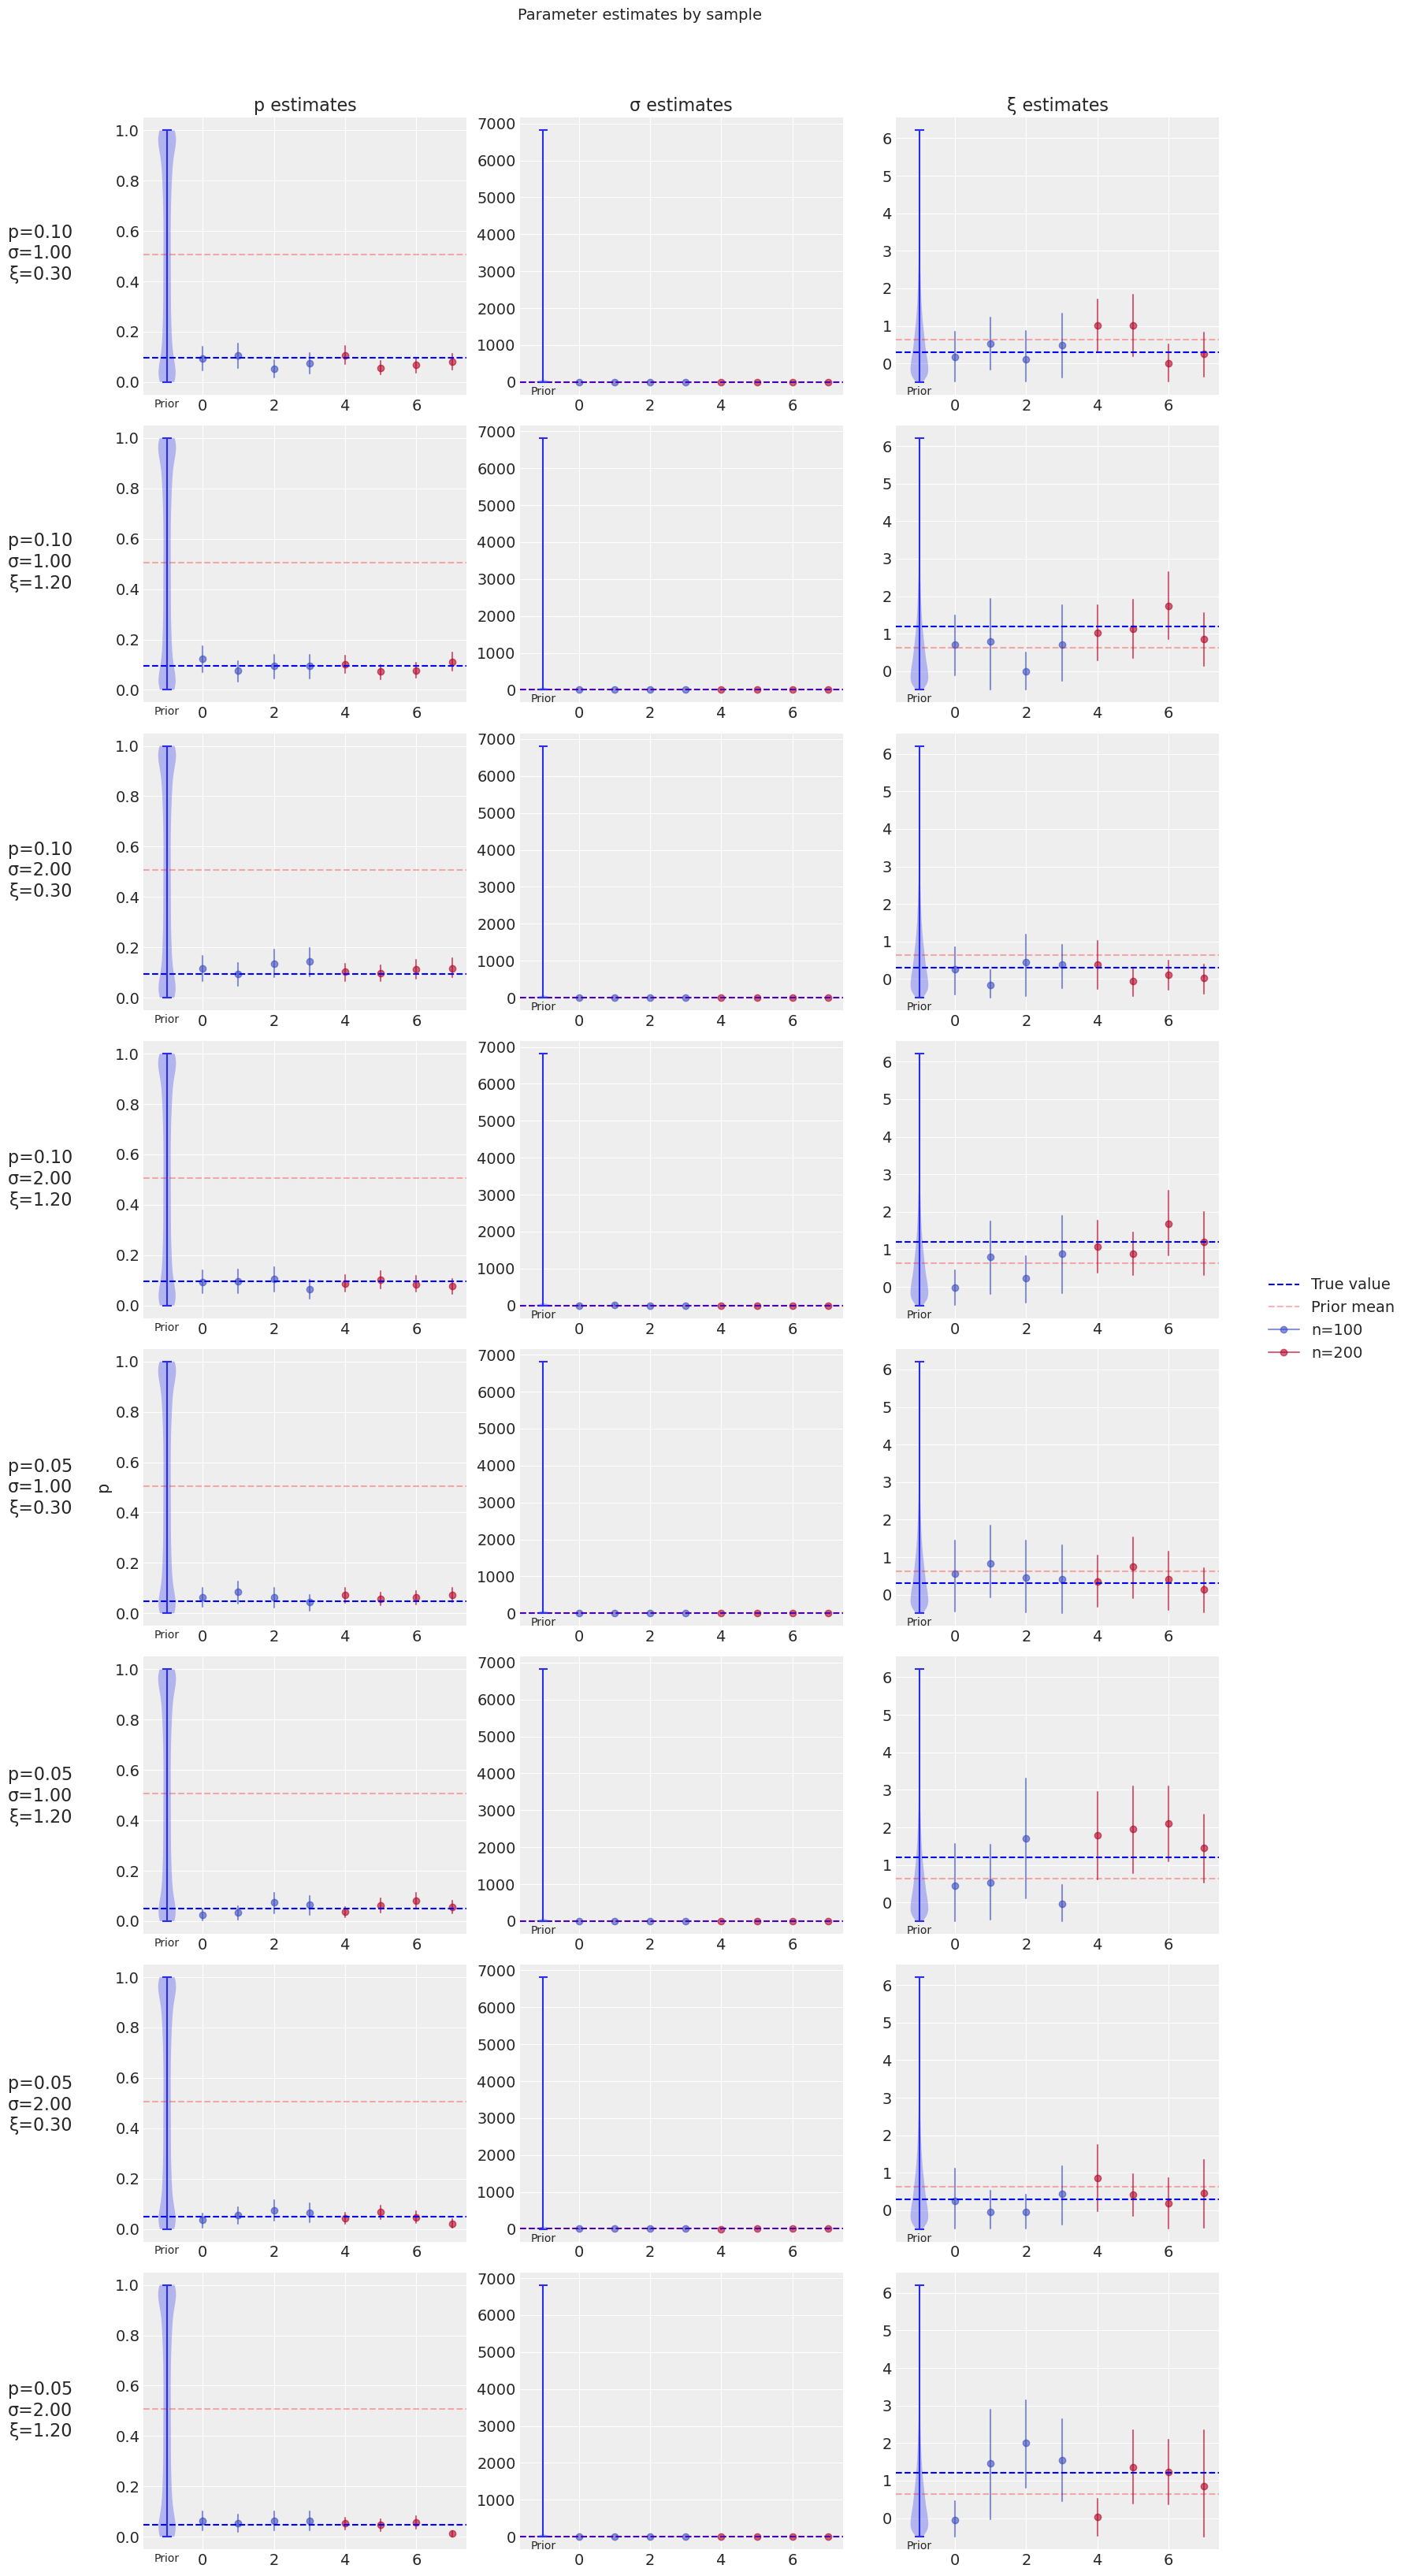

In [34]:
# Create figure with subplots for each parameter combination and parameter
param_combos = df[['p_true', 'sigma_true', 'xi_true']].drop_duplicates()
n_combos = len(param_combos)

# Create a grid of subplots - one row per parameter combo, one column per parameter
fig, axes = plt.subplots(n_combos, 3, figsize=(15, 4*n_combos))
fig.suptitle('Parameter estimates by sample', fontsize=14, y=1.02)

# Column titles
axes[0,0].set_title('p estimates')
axes[0,1].set_title('σ estimates') 
axes[0,2].set_title('ξ estimates')

# Get unique sample sizes and create colormap
sample_sizes = sorted(df['sample_ns'].unique())
colors = plt.cm.coolwarm(np.linspace(0, 1, len(sample_sizes)))
color_dict = dict(zip(sample_sizes, colors))

# Plot each parameter combination
for i, (_, combo) in enumerate(param_combos.iterrows()):
    # Get data for this parameter combination
    mask = ((df['p_true'] == combo['p_true']) & 
            (df['sigma_true'] == combo['sigma_true']) & 
            (df['xi_true'] == combo['xi_true']))
    subset = df[mask].sort_values('sample_ns')  # Sort by sample size
    
    # Create row label with true parameter values
    row_label = f'p={combo["p_true"]:.2f}\nσ={combo["sigma_true"]:.2f}\nξ={combo["xi_true"]:.2f}'
    
    # Plot p estimates
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,0].plot([j, j], [row['p_hdi_l'], row['p_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,0].plot(j, row['p_hat'], 'o', color=color, alpha=0.6)
    axes[i,0].axhline(y=combo['p_true'], color='b', linestyle='--')
    axes[i,0].axhline(y=prior_p.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,0].set_ylabel('p' if i == len(param_combos)//2 else '')
    # Add prior violin plot for p
    axes[i,0].violinplot([prior_p], [-1], points=100, widths=0.5)
    axes[i,0].text(-1, axes[i,0].get_ylim()[0] - 0.05, 'Prior', ha='center')

    # Plot sigma estimates  
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,1].plot([j, j], [row['sigma_hdi_l'], row['sigma_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,1].plot(j, row['sigma_hat'], 'o', color=color, alpha=0.6)
    axes[i,1].axhline(y=combo['sigma_true'], color='b', linestyle='--')
    axes[i,1].axhline(y=prior_sigma.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,1].set_ylabel('')
    # Add prior violin plot for sigma
    axes[i,1].violinplot([prior_sigma], [-1], points=100, widths=0.5)
    axes[i,1].text(-1, axes[i,1].get_ylim()[0] - 0.05, 'Prior', ha='center')
    
    # Plot xi estimates
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,2].plot([j, j], [row['xi_hdi_l'], row['xi_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,2].plot(j, row['xi_hat'], 'o', color=color, alpha=0.6)
    axes[i,2].axhline(y=combo['xi_true'], color='b', linestyle='--')
    axes[i,2].axhline(y=prior_xi.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,2].set_ylabel('')
    # Add prior violin plot for xi
    axes[i,2].violinplot([prior_xi], [-1], points=100, widths=0.5)
    axes[i,2].text(-1, axes[i,2].get_ylim()[0], 'Prior', ha='center')

    # Adjust layout first to get final subplot positions
    plt.tight_layout()
    plt.subplots_adjust(left=0.08)  # Increased left margin for labels
    
    # Add row label to the left of the first subplot after layout is set
    fig.text(0.02, axes[i,0].get_position().y0 + axes[i,0].get_position().height/2,
             row_label, rotation=0, ha='right', va='center', fontsize=16)

# Add legend
lines = [Line2D([0], [0], color='b', linestyle='--', label='True value'),
         Line2D([0], [0], color='r', linestyle='--', alpha=0.3, label='Prior mean')]

# Add sample size lines to legend
for n in sample_sizes:
    lines.append(Line2D([0], [0], color=color_dict[n], marker='o', linestyle='-', 
                       alpha=0.6, label=f'n={n}'))

fig.legend(handles=lines, bbox_to_anchor=(1.02, 0.5), loc='center left')

Same figure again but without the prior visualizations to reduce y axis limits.

C:\Users\squaade\AppData\Local\Temp\ipykernel_23116\602871928.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


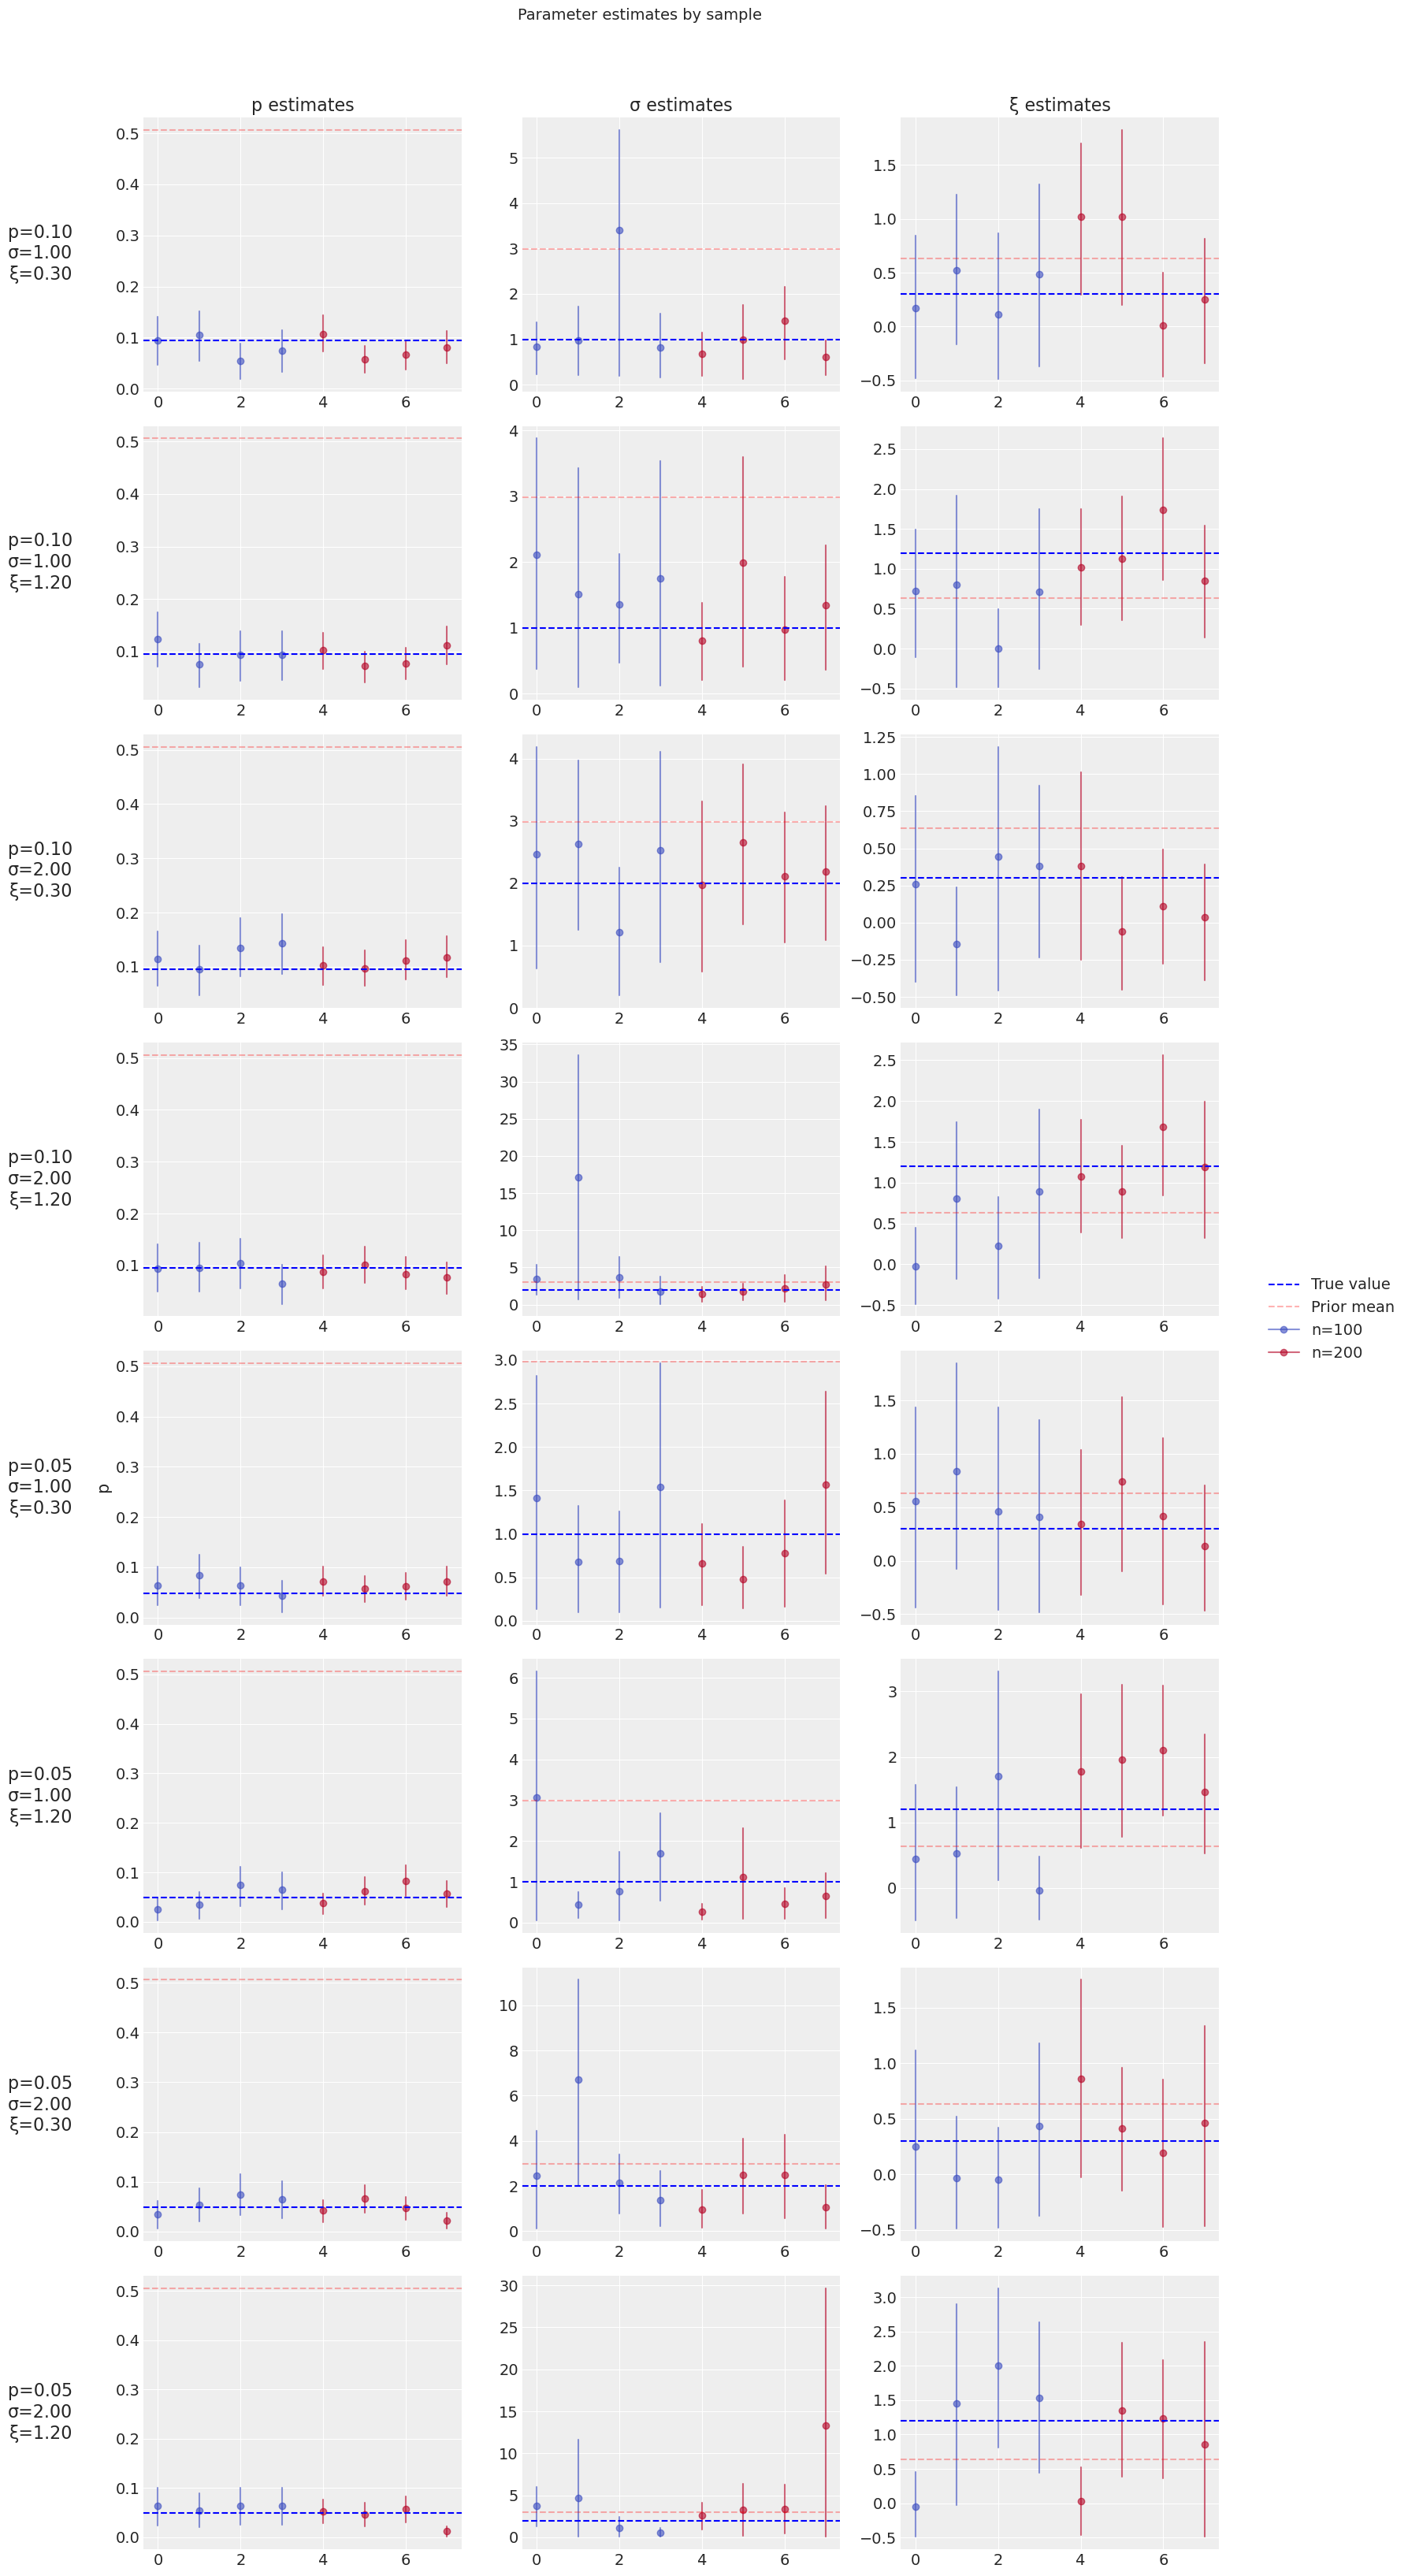

In [35]:
# Create figure with subplots for each parameter combination and parameter
param_combos = df[['p_true', 'sigma_true', 'xi_true']].drop_duplicates()
n_combos = len(param_combos)

# Create a grid of subplots - one row per parameter combo, one column per parameter
fig, axes = plt.subplots(n_combos, 3, figsize=(15, 4*n_combos))
fig.suptitle('Parameter estimates by sample', fontsize=14, y=1.02)

# Column titles
axes[0,0].set_title('p estimates')
axes[0,1].set_title('σ estimates') 
axes[0,2].set_title('ξ estimates')

# Get unique sample sizes and create colormap
sample_sizes = sorted(df['sample_ns'].unique())
colors = plt.cm.coolwarm(np.linspace(0, 1, len(sample_sizes)))
color_dict = dict(zip(sample_sizes, colors))

# Plot each parameter combination
for i, (_, combo) in enumerate(param_combos.iterrows()):
    # Get data for this parameter combination
    mask = ((df['p_true'] == combo['p_true']) & 
            (df['sigma_true'] == combo['sigma_true']) & 
            (df['xi_true'] == combo['xi_true']))
    subset = df[mask].sort_values('sample_ns')  # Sort by sample size
    
    # Create row label with true parameter values
    row_label = f'p={combo["p_true"]:.2f}\nσ={combo["sigma_true"]:.2f}\nξ={combo["xi_true"]:.2f}'
    
    # Plot p estimates
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,0].plot([j, j], [row['p_hdi_l'], row['p_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,0].plot(j, row['p_hat'], 'o', color=color, alpha=0.6)
    axes[i,0].axhline(y=combo['p_true'], color='b', linestyle='--')
    axes[i,0].axhline(y=prior_p.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,0].set_ylabel('p' if i == len(param_combos)//2 else '')
    # Add prior violin plot for p
    # axes[i,0].violinplot([prior_p], [-1], points=100, widths=0.5)
    # axes[i,0].text(-1, axes[i,0].get_ylim()[0] - 0.05, 'Prior', ha='center')

    # Plot sigma estimates  
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,1].plot([j, j], [row['sigma_hdi_l'], row['sigma_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,1].plot(j, row['sigma_hat'], 'o', color=color, alpha=0.6)
    axes[i,1].axhline(y=combo['sigma_true'], color='b', linestyle='--')
    axes[i,1].axhline(y=prior_sigma.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,1].set_ylabel('')
    # Add prior violin plot for sigma
    # axes[i,1].violinplot([prior_sigma], [-1], points=100, widths=0.5)
    # axes[i,1].text(-1, axes[i,1].get_ylim()[0] - 0.05, 'Prior', ha='center')
    
    # Plot xi estimates
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,2].plot([j, j], [row['xi_hdi_l'], row['xi_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,2].plot(j, row['xi_hat'], 'o', color=color, alpha=0.6)
    axes[i,2].axhline(y=combo['xi_true'], color='b', linestyle='--')
    axes[i,2].axhline(y=prior_xi.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,2].set_ylabel('')
    # Add prior violin plot for xi
    # axes[i,2].violinplot([prior_xi], [-1], points=100, widths=0.5)
    # axes[i,2].text(-1, axes[i,2].get_ylim()[0], 'Prior', ha='center')

    # Adjust layout first to get final subplot positions
    plt.tight_layout()
    plt.subplots_adjust(left=0.08)  # Increased left margin for labels
    
    # Add row label to the left of the first subplot after layout is set
    fig.text(0.02, axes[i,0].get_position().y0 + axes[i,0].get_position().height/2,
             row_label, rotation=0, ha='right', va='center', fontsize=16)

# Add legend
lines = [Line2D([0], [0], color='b', linestyle='--', label='True value'),
         Line2D([0], [0], color='r', linestyle='--', alpha=0.3, label='Prior mean')]

# Add sample size lines to legend
for n in sample_sizes:
    lines.append(Line2D([0], [0], color=color_dict[n], marker='o', linestyle='-', 
                       alpha=0.6, label=f'n={n}'))

fig.legend(handles=lines, bbox_to_anchor=(1.02, 0.5), loc='center left')

C:\Users\squaade\AppData\Local\Temp\ipykernel_23116\3170889176.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


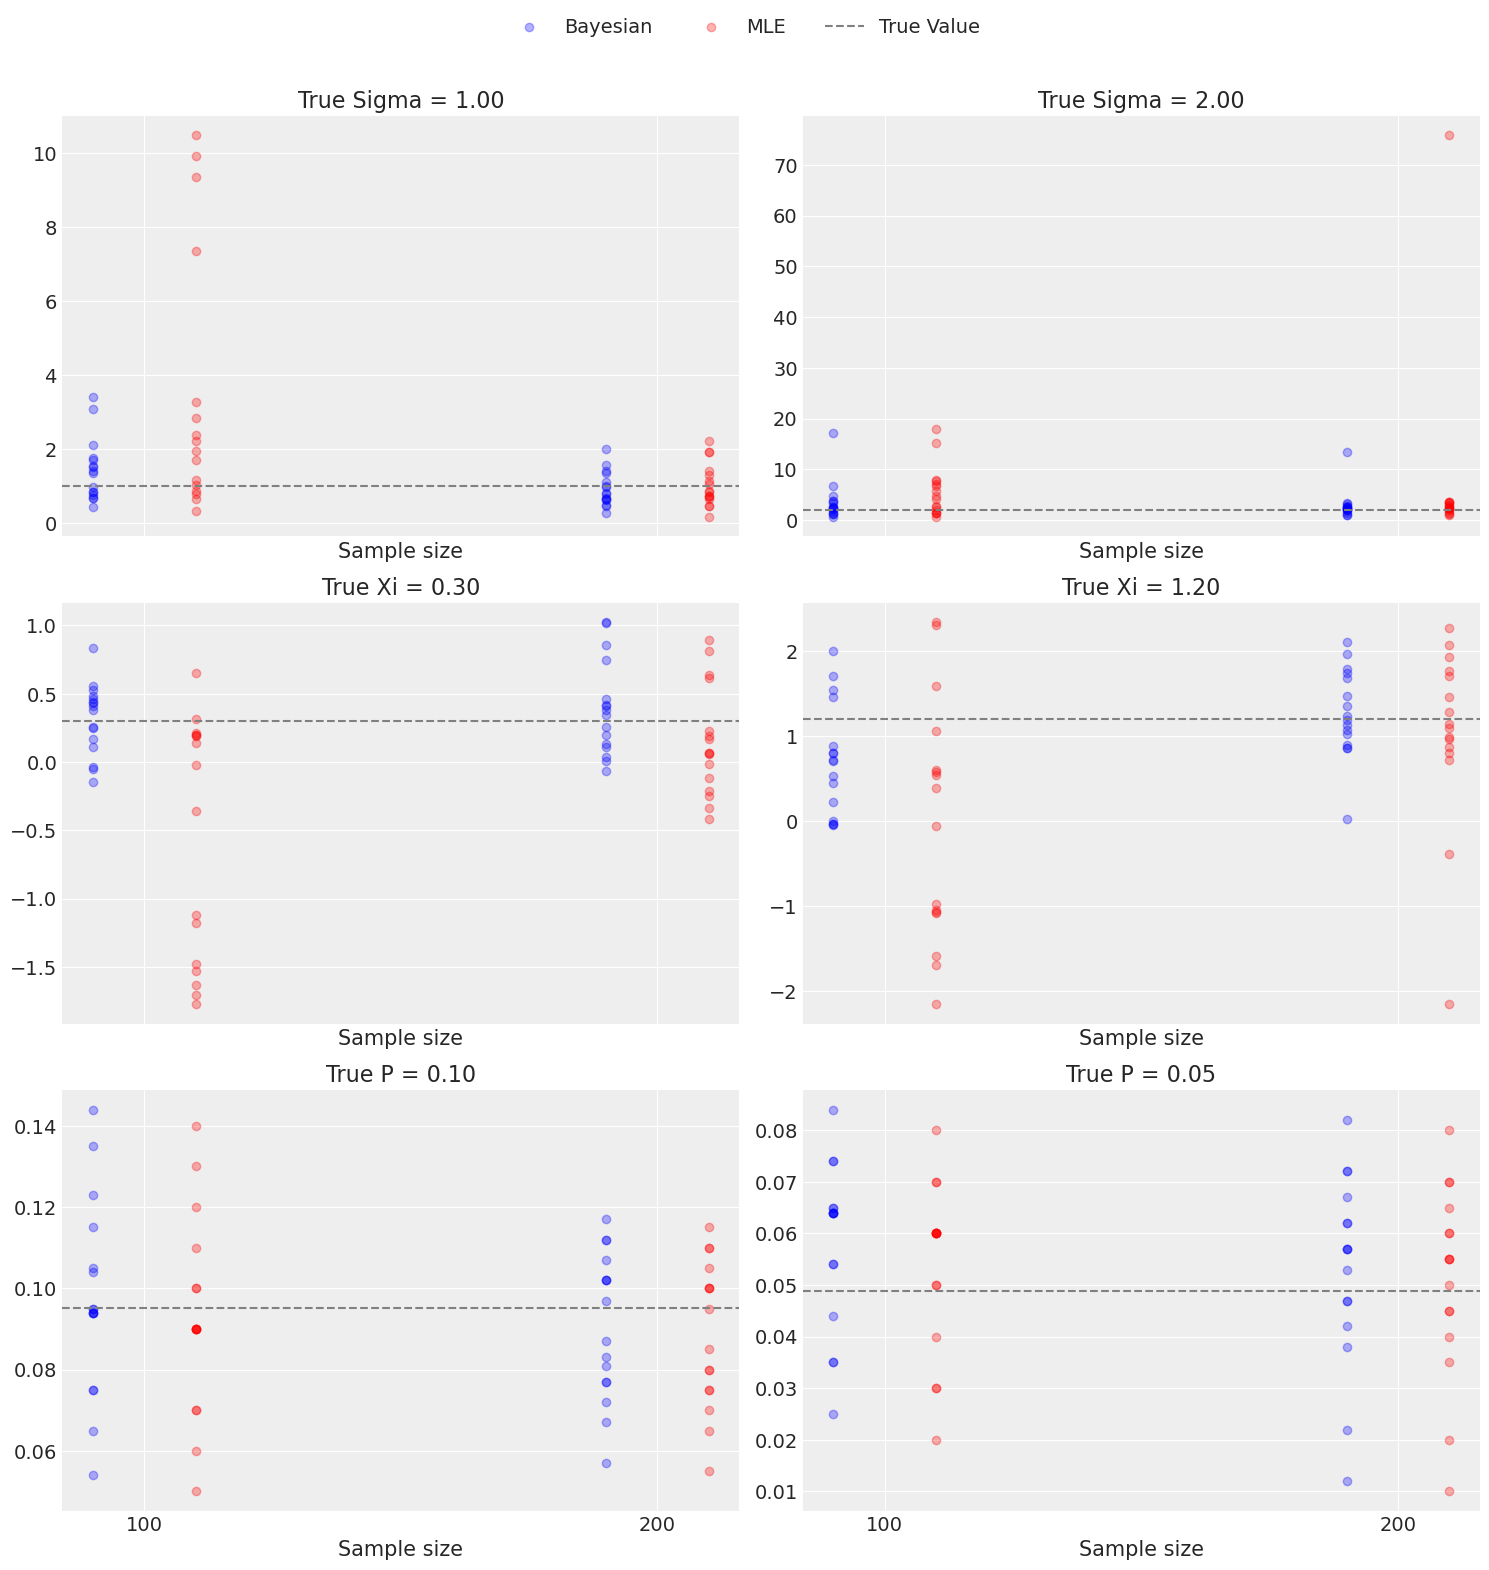

In [45]:
# Parameters to plot
parameters = ['sigma', 'xi', 'p']

# Create a figure with subplots for each parameter and its true values
fig, axes = plt.subplots(nrows=len(parameters), ncols=max(len(df[f'{param}_true'].unique()) for param in parameters), 
                         figsize=(15, 5 * len(parameters)), sharex=True)

# Create offset for side-by-side plotting
unique_n = sorted(df['n'].unique())
x_positions = np.arange(len(unique_n))
width = 0.2

# Map the scatter plots for Bayesian and MLE estimates for each parameter
for i, param in enumerate(parameters):
    true_values = df[f'{param}_true'].unique()
    
    for j, true_value in enumerate(true_values):
        ax = axes[i, j]
        subset = df[df[f'{param}_true'] == float(true_value)]
        
        # Plot individual Bayesian estimates
        for n_idx, n in enumerate(unique_n):
            n_subset = subset[subset['n'] == n]
            ax.scatter([x_positions[n_idx] - width/2] * len(n_subset), 
                       n_subset[f'{param}_hat'],
                       color='blue', alpha=0.3, label='Bayesian' if n_idx == 0 and j == 0 else '')
        
        # Plot individual MLE estimates
        for n_idx, n in enumerate(unique_n):
            n_subset = subset[subset['n'] == n]
            ax.scatter([x_positions[n_idx] + width/2] * len(n_subset),
                       n_subset[f'{param}_mle'],
                       color='red', alpha=0.3, label='MLE' if n_idx == 0 and j == 0 else '')
        
        # Add horizontal line for true value
        ax.axhline(y=float(true_value), color='gray', linestyle='--', label='True Value' if j == 0 else '')
        
        # Set x-ticks to sample sizes
        ax.set_xticks(x_positions)
        ax.set_xticklabels(unique_n)
        
        # Add titles and labels
        ax.set_xlabel('Sample size')
        ax.set_title(f'True {param.capitalize()} = {true_value:.2f}')

# Add a single legend for the entire figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()

In general the Bayesian approach seems to provide better mean estimates than the MLE!

Note: we could also explore whether the median is a better esitmator than the mean.

Having convinced ourselves that the Bayesian approach yields sensible estimates, we apply to our actual pandemic data. We then provide crude estimate of expected annual mortality by sampling from both our intensity and duration distributions.

In [43]:
intensity_data = final_allrisk_ds.set_index('year_start')['intensity']

# Fill in zeros for years with no observations.
all_years = pd.Series(range(1900, 2023 + 1))
intensity_data = intensity_data.reindex(all_years, fill_value=0)

In [44]:
with make_intensity_model(intensity_data, THRESHOLD) as model:
    idata = pm.sample(draws=20_000,
                      tune=3_000,
                      chains=cores,
                      random_seed=rng_master,
                      target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [xi_raw, log_sigma, p]


Output()

Sampling 4 chains for 3_000 tune and 20_000 draw iterations (12_000 + 80_000 draws total) took 55 seconds.
There were 748 divergences after tuning. Increase `target_accept` or reparameterize.


In [45]:
posterior = idata.posterior

array([[<Axes: title={'center': 'lambda'}>,
        <Axes: title={'center': 'p'}>, <Axes: title={'center': 'xi'}>],
       [<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'sigma'}>, <Axes: >]], dtype=object)

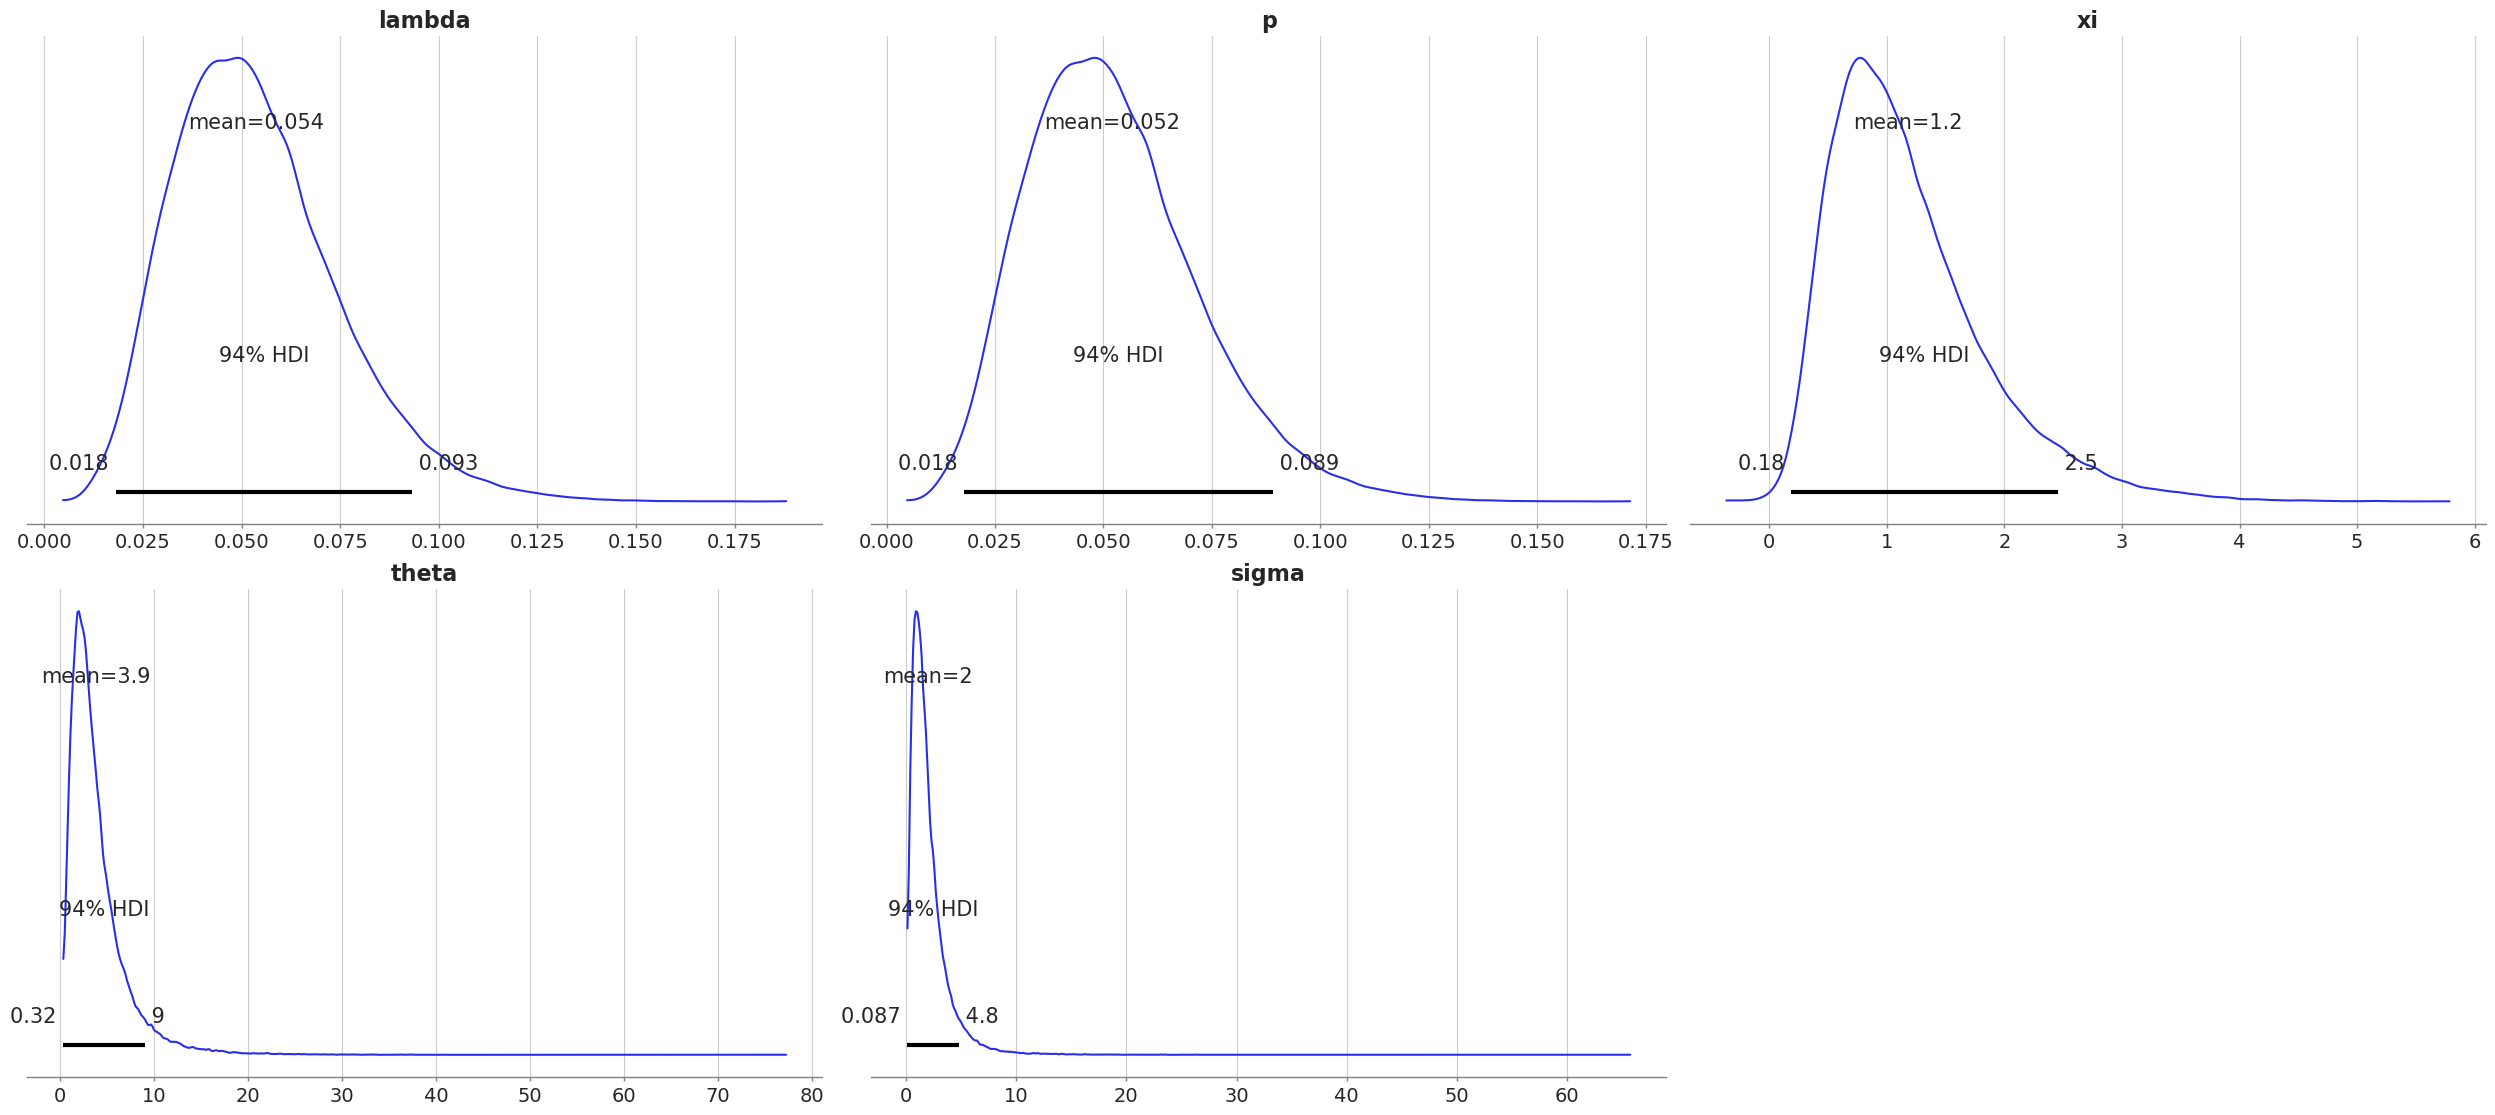

In [46]:
az.plot_posterior(posterior, var_names=var_names)

In [47]:
# Also fit the MLE estimate for comparison
exceed_data = intensity_data[intensity_data > 0]
mle_xi, _, mle_sigma = scipy.stats.genpareto.fit(exceed_data, floc=THRESHOLD)
mle_p = np.sum(intensity_data > 0) / len(intensity_data)

C:\Users\squaade\AppData\Local\Temp\ipykernel_43012\4241422253.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


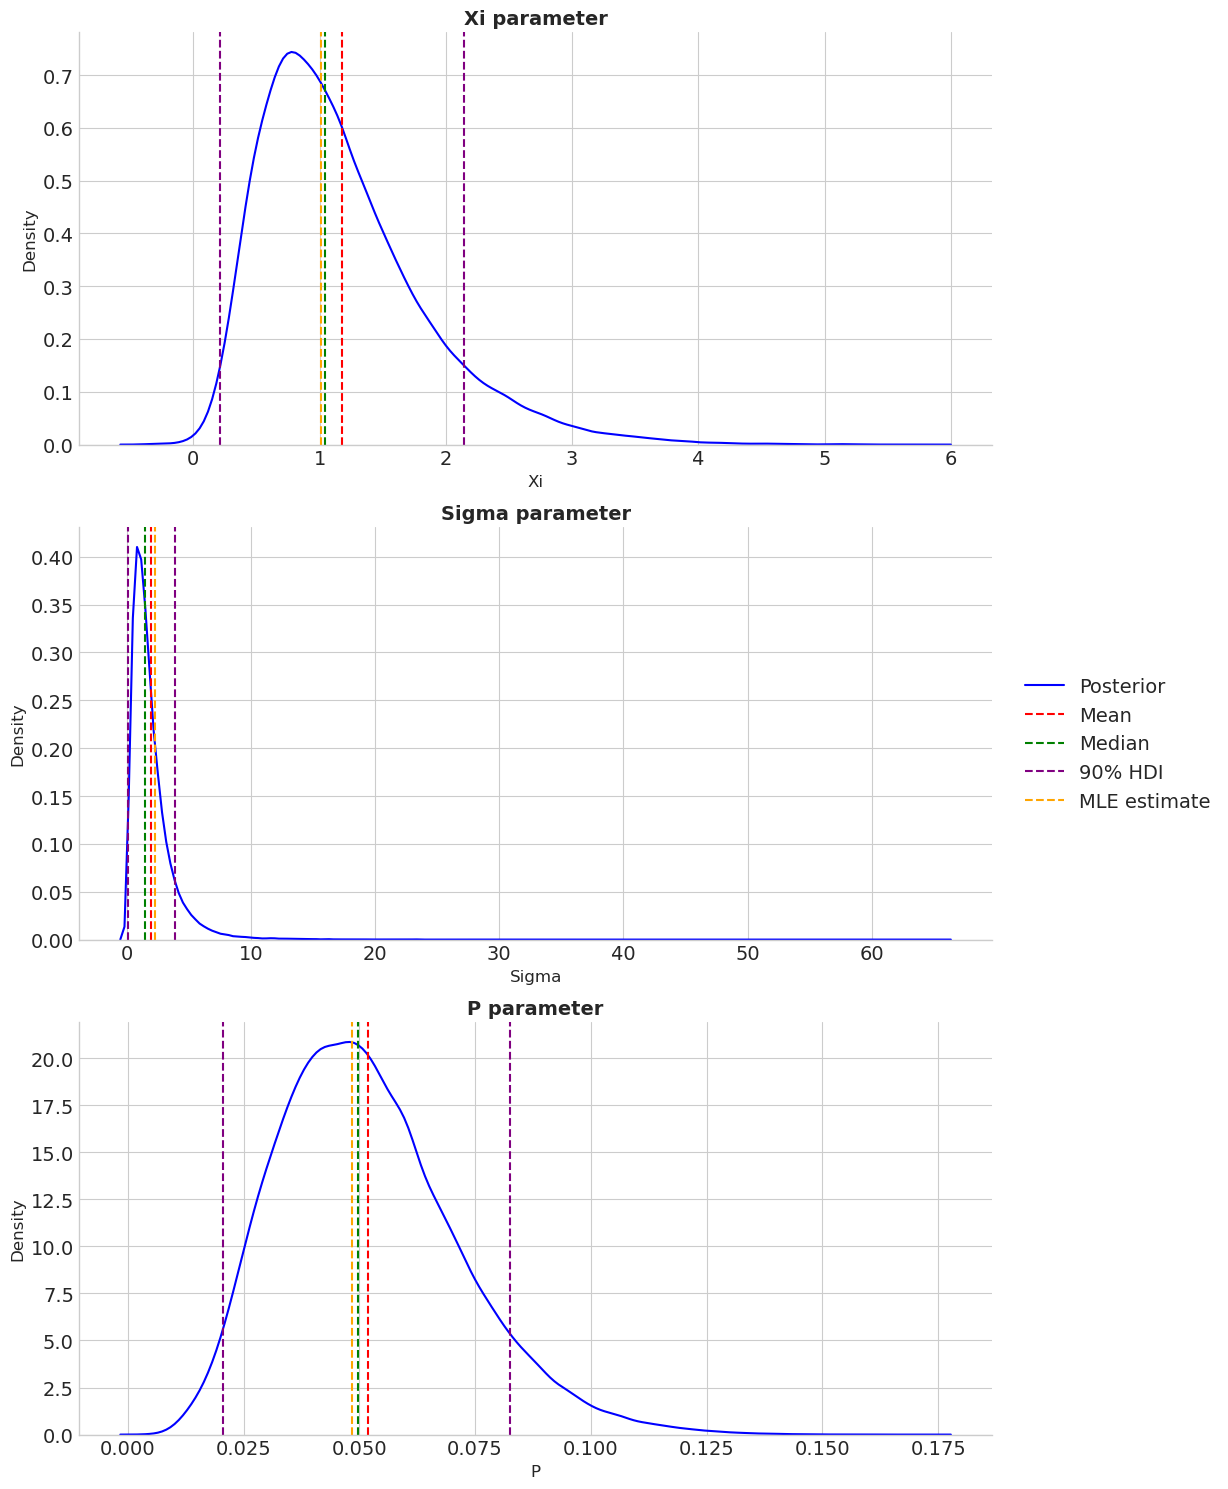

In [54]:
# Plot mean, median, and HDIs for each parameter: xi, sigma, and p
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Define the parameters to plot
parameters = ['xi', 'sigma', 'p']
mle_estimates = [mle_xi, mle_sigma, mle_p]

for i, param in enumerate(parameters):
    # Extract the data for the parameter
    param_data = posterior[param].values.flatten()
    
    # Calculate statistics
    mean_val = np.mean(param_data)
    median_val = np.median(param_data)
    hdi_5, hdi_95 = az.hdi(param_data, hdi_prob=0.9)
    
    # Plot the KDE with clipping for 'sigma' and 'p'
    sns.kdeplot(param_data, ax=axes[i], label=f'Posterior', color='blue')
    
    # Plot mean, median, and HDI
    axes[i].axvline(mean_val, color='red', linestyle='--', label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='--', label='Median')
    axes[i].axvline(hdi_5, color='purple', linestyle='--', label='90% HDI')
    axes[i].axvline(hdi_95, color='purple', linestyle='--')
    
    # Plot MLE estimate
    axes[i].axvline(mle_estimates[i], color='orange', linestyle='--', label='MLE estimate')
    
    # Set titles and labels
    axes[i].set_title(f'{param.capitalize()} parameter', fontsize=14)
    axes[i].set_xlabel(param.capitalize(), fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)

# Add a single legend to the right of the figure, ensuring it doesn't repeat for each subplot
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


Finally, let's compose the duration and intensity posterior to get a rough estimate of expected annual mortality.

In [129]:
n_samples = int(1e6) # One million draws
population = 7.91e9

**Duration sampling**. Let's use the posterior from the calibrated NIG model.

In [130]:
dur_mu_samples, dur_sigma_samples = cal_nig_updater.sample_posterior(n_samples, rng=rng_master)
duration_draws = scipy.stats.lognorm.rvs(s=dur_sigma_samples, scale=np.exp(dur_mu_samples), random_state=rng_master)
duration_draws[duration_draws > TRUNC_YEARS] = TRUNC_YEARS

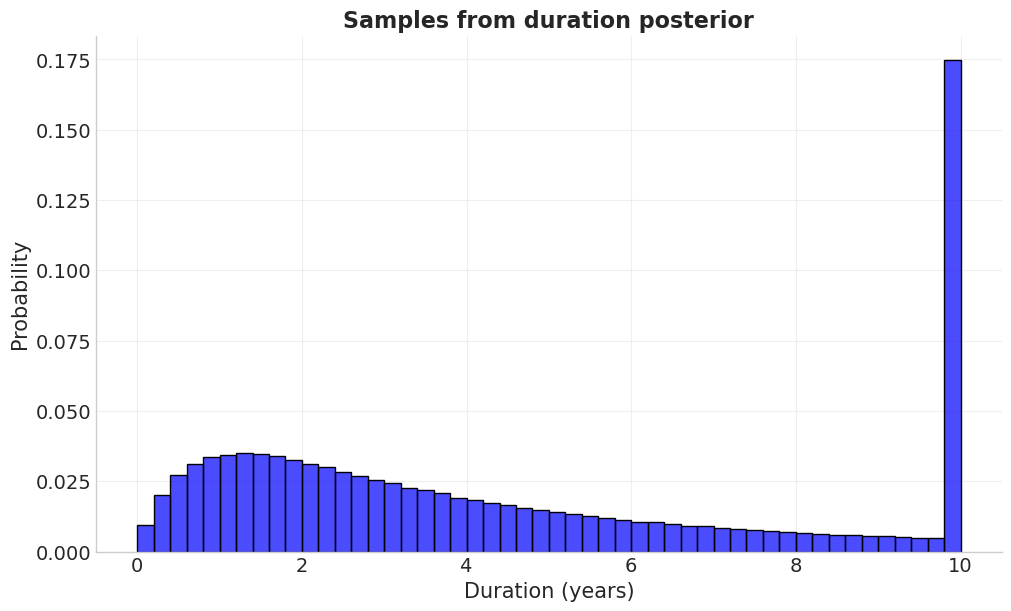

In [131]:
# Plot distribution of duration samples using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(data=duration_draws, stat='probability', bins=50, alpha=0.7, color='blue', label='Duration samples')
plt.xlabel('Duration (years)')
plt.ylabel('Probability')
plt.title('Samples from duration posterior')
plt.grid(True, alpha=0.3)
plt.show()


**Intensity sampling**. This requires more computation to get one million samples. Maybe there's a better way. Perhaps thinner sampling and interpolation is fine?

In [ ]:
with make_intensity_model(intensity_data, THRESHOLD) as model:
    idata = pm.sample(draws=n_samples // cores,
                      tune=3_000,
                      chains=cores,
                      random_seed=rng_master,
                      target_accept=0.9)

posterior_big_sample = idata.posterior

I'm not overly concerned about the divergences at the moment. They're at about 1% of the draws, and my earlier investigation suggests they essentially occur around sigma is zero. It could be something to tune at a later date.

In [142]:
# Sample the intensity model parameters from the
int_xi_samples = posterior_big_sample['xi'].values.flatten()
int_sigma_samples = posterior_big_sample['sigma'].values.flatten()
int_p_samples = posterior_big_sample['p'].values.flatten()

arrival_draws = scipy.stats.bernoulli.rvs(int_p_samples)
cond_intensity_draws = scipy.stats.genpareto.rvs(int_xi_samples, loc=THRESHOLD, scale=int_sigma_samples)
intensity_draws = arrival_draws * cond_intensity_draws

In [143]:
MAX_INTENSITY = 1000 # Ex post truncation limit

In [145]:
intensity_draws[intensity_draws > MAX_INTENSITY] = MAX_INTENSITY

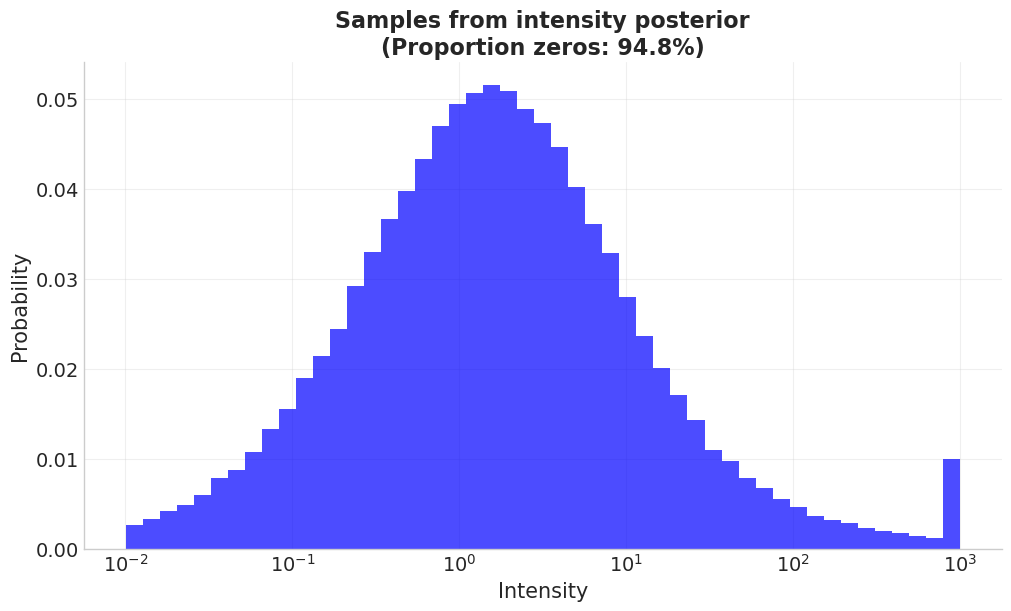

In [150]:
# Plot distribution of intensity samples using seaborn
plt.figure(figsize=(10, 6))

# Calculate proportion of zeros
n_zeros = np.sum(intensity_draws == 0)
prop_zeros = n_zeros / len(intensity_draws)

# Plot non-zero values on log scale
nonzero_draws = intensity_draws[intensity_draws > 0]
bins = np.logspace(np.log10(nonzero_draws.min()), np.log10(nonzero_draws.max()), 50)
sns.histplot(data=nonzero_draws, stat='probability', bins=bins, alpha=0.7, color='blue', label='Non-zero intensities')

plt.xscale('log')
plt.xlabel('Intensity')
plt.ylabel('Probability')
plt.title(f'Samples from intensity posterior\n(Proportion zeros: {prop_zeros:.1%})')
plt.grid(True, alpha=0.3)
plt.show()


In [183]:
# Pandemic intensity with MLE
exceed_data = intensity_data[intensity_data > 0]
mle_xi, _, mle_int_sigma = scipy.stats.genpareto.fit(exceed_data, floc=THRESHOLD)
mle_p = np.sum(intensity_data > 0) / len(intensity_data)

C:\Users\squaade\AppData\Local\Temp\ipykernel_43012\1854658288.py:45: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


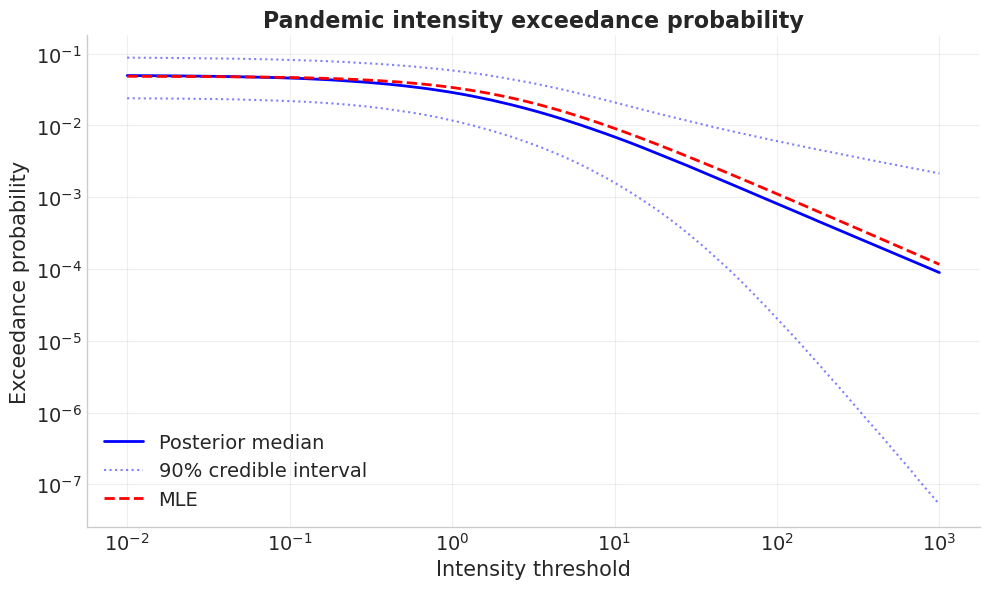

In [185]:
# Create intensity thresholds
intensity_thresholds = np.logspace(np.log10(THRESHOLD), np.log10(MAX_INTENSITY), 1000)
intensity_thresholds_mat = np.tile(intensity_thresholds, (100_000, 1)).T

# Calculate survival functions for each sample
intensity_survivals = (
    int_p_samples[:100_000] * scipy.stats.genpareto.sf(
        intensity_thresholds_mat, 
        int_xi_samples[:100_000],
        loc=THRESHOLD,
        scale=int_sigma_samples[:100_000]
    )
)

# Calculate percentiles for credible intervals
intensity_percentiles = np.percentile(intensity_survivals, [5, 50, 95], axis=1)

# Calculate MLE survival function
mle_survivals = mle_p * scipy.stats.genpareto.sf(
    intensity_thresholds,
    mle_xi,
    loc=THRESHOLD,
    scale=mle_int_sigma
)

# Plot exceedance probability curve
plt.figure(figsize=(10, 6))

# Plot median and credible intervals
plt.plot(intensity_thresholds, intensity_percentiles[1], 'b-', linewidth=2, label='Posterior median')
plt.plot(intensity_thresholds, intensity_percentiles[0], 'b:', alpha=0.5, label='90% credible interval')
plt.plot(intensity_thresholds, intensity_percentiles[2], 'b:', alpha=0.5)

# Plot MLE
plt.plot(intensity_thresholds, mle_survivals, 'r--', linewidth=2, label='MLE')

plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.xlabel('Intensity threshold')
plt.ylabel('Exceedance probability')
plt.title('Pandemic intensity exceedance probability')
plt.legend()

plt.tight_layout()
plt.show()

Note that I am not using the total amount we sampled as I'm worried about running out of memory. It's possible these intervals are not small enough.

### Expected annual mortality

Finally, let's estimate expected annual mortality using both MLE and our Bayesian approach.

Note that I'm not certain about how to best report uncertainty in this statistic. Taking percentiles across the range samples generally renders the mean outside the credible intervals because pandemic arrival is infrequent. I demonstrate this below with what I term the "direct method".

As an alternative, I bootstrap our annual mortality samples and take the percentiles of the means across each bootstrap sample to generate a confidence interval. This seems reasonable, but I haven't through carefully about what the confidence intervals truly represent.

We start with the Bayesian approach:

In [182]:
# Calculate annual mortality for all samples
annual_mortality_samples = (intensity_draws[:n_samples] / duration_draws[:n_samples]) * (population / 10_000) # Reduce sample size to ease computation

# Approach 1: Direct percentile method
mean_mortality = np.mean(annual_mortality_samples)
median_mortality = np.median(annual_mortality_samples)
ci_lower, ci_upper = np.percentile(annual_mortality_samples, [5, 95])

# Approach 2: Bootstrap of the mean
n_bootstrap = 10000
bootstrap_means = np.zeros(n_bootstrap)
for i in range(n_bootstrap):
    bootstrap_sample = np.random.choice(annual_mortality_samples, size=len(annual_mortality_samples), replace=True)
    bootstrap_means[i] = np.mean(bootstrap_sample)

bootstrap_ci_lower, bootstrap_ci_upper = np.percentile(bootstrap_means, [5, 95])

# Print results
print("Bayesian estimates:")
print(f"Direct method:")
print(f"Mean: {mean_mortality:,.0f}")
print(f"90% CI: [{ci_lower:,.0f}, {ci_upper:,.0f}]")
print(f"\nBootstrap method (uncertainty in mean):")
print(f"90% CI for mean: [{bootstrap_ci_lower:,.0f}, {bootstrap_ci_upper:,.0f}]")

Bayesian estimates:
Direct method:
Mean: 514,241
90% CI: [0, 8,289]

Bootstrap method (uncertainty in mean):
90% CI for mean: [410,827, 630,488]


In [ ]:
# Generate samples using MLE estimates

n_samples = 100_000
mle_intensity_samples = scipy.stats.genpareto.rvs(
    c=mle_xi, 
    loc=THRESHOLD, 
    scale=mle_int_sigma, 
    size=n_samples
) * (np.random.random(n_samples) < mle_p)

mle_dur_sigma, _, mle_mu = scipy.stats.lognorm.fit(duration_data, floc=0)
mle_mu = np.log(mle_mu)

# Generate MLE duration samples
mle_duration_samples = np.random.lognormal(mean=mle_mu, sigma=mle_dur_sigma, size=n_samples)

# Calculate annual mortality using MLE samples
mle_annual_mortality_samples = (mle_intensity_samples / mle_duration_samples) * (population / 10_000)

# Calculate statistics - direct method
mle_mean_mortality = np.mean(mle_annual_mortality_samples)
mle_ci_lower, mle_ci_upper = np.percentile(mle_annual_mortality_samples, [5, 95])

# Bootstrap method
n_bootstrap = 10000
mle_bootstrap_means = np.zeros(n_bootstrap)
for i in range(n_bootstrap):
    bootstrap_sample = np.random.choice(mle_annual_mortality_samples, size=len(mle_annual_mortality_samples), replace=True)
    mle_bootstrap_means[i] = np.mean(bootstrap_sample)

mle_bootstrap_ci_lower, mle_bootstrap_ci_upper = np.percentile(mle_bootstrap_means, [5, 95])

print(f"\nMLE estimates:")
print(f"Direct method:")
print(f"Mean annual mortality: {mle_mean_mortality:,.0f}")
print(f"90% CI: [{mle_ci_lower:,.0f}, {mle_ci_upper:,.0f}]")
print(f"\nBootstrap method (uncertainty in mean):")
print(f"90% CI for mean: [{mle_bootstrap_ci_lower:,.0f}, {mle_bootstrap_ci_upper:,.0f}]")



MLE estimates:
Direct method:
Mean annual mortality: 526,970
90% CI: [0, 0]

Bootstrap method (uncertainty in mean):
90% CI for mean: [373,991, 701,477]


The results are pretty similar! But I don't understand why the bootstrap CIs are narrower for the Bayesian than the MLE.

## Conclusion

This concludes our prototyping of the Bayesian approach to fitting the model. Some key things to discuss:
- Are we convinced that the Bayesian approach provides reasonable estimates for our distributions of interest?
- What should we do about truncation? The sharp ex post truncation is very ad hoc, only justified in terms of conservatism. For the epidemic intensity model, we could use the Cirillo and Taleb transform. I am not sure there is a good solution for the lognormal distribution. We could also use analytically truncated distributions, but this would require us to move away from the reference prior setup.
- What is the right way to quantify uncertainty in our expected annual mortality estimate?